<a href="https://colab.research.google.com/github/sthavirpunwatkar/PGCP-AI-Deep_Learning/blob/main/DNN_Lab_pgcpai_cdac_cine_feb26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**LAB SESSION 1 (22-04-2026) - Deep Learning Foundations: Activation Functions**
---
**Topic:** Implementing and Comparing Sigmoid, Tanh, and ReLU
1. Generate a non-linear toy dataset (Two Moons).
2. Build a simple 1-hidden-layer Neural Network using PyTorch.
3. Train the network three separate times, using a different activation function each time.
4. Visualize the loss curves and the final decision boundaries to see how each function performs.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, load_iris, load_digits
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim

%matplotlib inline

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

In [ ]:
# Generate the dataset
X, y = make_moons(n_samples=500, noise=0.15, random_state=42)

# Convert to PyTorch tensors
X_tensor = torch.FloatTensor(X)
y_tensor = torch.FloatTensor(y).reshape(-1, 1)

# Plot the dataset
plt.figure(figsize=(8, 6))
plt.scatter(X[y==0, 0], X[y==0, 1], color='red', label='Class 0', alpha=0.7)
plt.scatter(X[y==1, 0], X[y==1, 1], color='blue', label='Class 1', alpha=0.7)
plt.title("Two Moons Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

In [ ]:
class SimpleNN(nn.Module):
    def __init__(self, activation_fn):
        super(SimpleNN, self).__init__()
        self.hidden = nn.Linear(2, 10)  # 2 input features, 10 hidden neurons
        self.output = nn.Linear(10, 1)  # 10 hidden neurons, 1 output
        self.activation = activation_fn
        self.sigmoid = nn.Sigmoid()     # Final output activation for binary classification

    def forward(self, x):
        x = self.hidden(x)
        x = self.activation(x)          # Apply the chosen hidden activation function
        x = self.output(x)
        x = self.sigmoid(x)             # Squash output to [0, 1] probability
        return x

In [ ]:
def train_model(model, X, y, epochs=1000, lr=0.5):
    criterion = nn.BCELoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)

    losses = []

    for epoch in range(epochs):
        # Forward pass
        predictions = model(X)
        loss = criterion(predictions, y)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    return losses

In [ ]:
# Initialize models
model_sigmoid = SimpleNN(nn.Sigmoid())
model_tanh = SimpleNN(nn.Tanh())
model_relu = SimpleNN(nn.ReLU())

# Train models
print("Training Sigmoid Model...")
loss_sigmoid = train_model(model_sigmoid, X_tensor, y_tensor)

print("Training Tanh Model...")
loss_tanh = train_model(model_tanh, X_tensor, y_tensor)

print("Training ReLU Model...")
loss_relu = train_model(model_relu, X_tensor, y_tensor)

# Plot Loss Curves
plt.figure(figsize=(10, 6))
plt.plot(loss_sigmoid, label='Sigmoid', color='blue')
plt.plot(loss_tanh, label='Tanh', color='green')
plt.plot(loss_relu, label='ReLU', color='red')
plt.title("Training Loss Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Binary Cross Entropy Loss")
plt.legend()
plt.show()

In [ ]:
def plot_decision_boundary(model, X, y, title, ax):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    # Create a grid
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))

    # Flatten grid and pass to model
    grid_tensor = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])
    with torch.no_grad():
        preds = model(grid_tensor)
        preds = (preds > 0.5).float().numpy()

    Z = preds.reshape(xx.shape)

    # Plot contour and scatter
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdBu)
    ax.scatter(X[y==0, 0], X[y==0, 1], color='red', edgecolors='k', marker='o', label='Class 0')
    ax.scatter(X[y==1, 0], X[y==1, 1], color='blue', edgecolors='k', marker='^', label='Class 1')
    ax.set_title(title)

# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_decision_boundary(model_sigmoid, X, y, "Sigmoid Decision Boundary", axes[0])
plot_decision_boundary(model_tanh, X, y, "Tanh Decision Boundary", axes[1])
plot_decision_boundary(model_relu, X, y, "ReLU Decision Boundary", axes[2])

plt.tight_layout()
plt.show()

In [ ]:
# 1. Load Iris instead of Moons
iris = load_iris()
# Use only first 2 features for easy 2D plotting; use all 4 features for better accuracy
X = iris.data[:, :2]
y = iris.target

X_tensor = torch.FloatTensor(X)
y_tensor = torch.LongTensor(y) # CrossEntropy expects Long labels

plt.figure(figsize=(8, 6))
plt.scatter(X[y==0, 0], X[y==0, 1], color='red', label='Class 0', alpha=0.7)
plt.scatter(X[y==1, 0], X[y==1, 1], color='blue', label='Class 1', alpha=0.7)
plt.scatter(X[y==2, 0], X[y==2, 1], color='green', label='Class 2', alpha=0.7)
plt.title("Iris Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

# 2. Update Model for Multiclass
class SimpleNN(nn.Module):
    def __init__(self, activation_fn):
        super(SimpleNN, self).__init__()
        self.hidden = nn.Linear(2, 10) # 2 input features (Sepal L/W)
        self.output = nn.Linear(10, 3) # 3 output classes (Setosa, Versicolor, Virginica)
        self.activation = activation_fn

    def forward(self, x):
        x = self.activation(self.hidden(x))
        x = self.output(x)
        # No Sigmoid here! nn.CrossEntropyLoss handles Logits internally
        return x

# 3. Update Training Function
def train_model(model, X, y, epochs=1000, lr=0.1):
    criterion = nn.CrossEntropyLoss() # Change for Multiclass
    optimizer = optim.SGD(model.parameters(), lr=lr)
    losses = []

    for epoch in range(epochs):
        predictions = model(X)
        loss = criterion(predictions, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return losses

# Initialize and Train
model_sigmoid = SimpleNN(nn.Sigmoid())
model_tanh = SimpleNN(nn.Tanh())
model_relu = SimpleNN(nn.ReLU())

loss_sigmoid = train_model(model_sigmoid, X_tensor, y_tensor)
loss_tanh = train_model(model_tanh, X_tensor, y_tensor)
loss_relu = train_model(model_relu, X_tensor, y_tensor)

plt.figure(figsize=(10, 6))
plt.plot(loss_sigmoid, label='Sigmoid', color='blue')
plt.plot(loss_tanh, label='Tanh', color='green')
plt.plot(loss_relu, label='ReLU', color='red')
plt.title("Training Loss Over Epochs")
plt.xlabel("Epochs")
plt.ylabel("Cross Entropy Loss")
plt.legend()
plt.show()

# 4. Update Decision Boundary Function
def plot_decision_boundary(model, X, y, title, ax):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

    grid_tensor = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])
    with torch.no_grad():
        logits = model(grid_tensor)
        _, preds = torch.max(logits, 1) # Get class with highest score
        Z = preds.reshape(xx.shape).numpy()

    ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.brg)
    for i, color in zip(range(3), ['red', 'green', 'blue']):
        ax.scatter(X[y==i, 0], X[y==i, 1], color=color, edgecolors='k', label=f'Class {i}')
    ax.set_title(title)

# Plotting code remains the same as your previous block
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_decision_boundary(model_sigmoid, X, y, "Sigmoid Decision Boundary", axes[0])
plot_decision_boundary(model_tanh, X, y, "Tanh Decision Boundary", axes[1])
plot_decision_boundary(model_relu, X, y, "ReLU Decision Boundary", axes[2])

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler

# 1. Load Scikit-learn digits (Small version of MNIST)
digits = load_digits()
X, y = digits.data, digits.target  # X is 64 features (8x8 flattened)

# Normalize for better convergence
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_tensor = torch.FloatTensor(X_scaled)
y_tensor = torch.LongTensor(y)  # LongTensor for CrossEntropy

class SimpleNN(nn.Module):
    def __init__(self, activation_fn):
        super(SimpleNN, self).__init__()
        self.hidden = nn.Linear(64, 32) # 64 inputs -> 32 hidden
        self.output = nn.Linear(32, 10) # 32 hidden -> 10 classes (0-9)
        self.activation = activation_fn

    def forward(self, x):
        x = self.activation(self.hidden(x))
        x = self.output(x)             # Raw scores (logits)
        return x

def train_model(model, X, y, epochs=500, lr=0.1):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr)
    losses = []

    for epoch in range(epochs):
        predictions = model(X)
        loss = criterion(predictions, y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    return losses

from sklearn.decomposition import PCA

# Reduce 64D to 2D for plotting
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Now you can use your previous plot_decision_boundary function
# by training a NEW model on X_pca (2 inputs) instead of 64.
# Plotting code remains the same as your previous block
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_decision_boundary(model_sigmoid, X, y, "Sigmoid Decision Boundary", axes[0])
plot_decision_boundary(model_tanh, X, y, "Tanh Decision Boundary", axes[1])
plot_decision_boundary(model_relu, X, y, "ReLU Decision Boundary", axes[2])

plt.tight_layout()
plt.show()

#lab 25-04-2026

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import time

#tenserflow
import tensorflow as tf
from tensorflow.keras import layers, models

#pytorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

np.random.seed(42)
tf.random.set_seed(42)
torch.manual_seed(42)

In [ ]:
data = load_breast_cancer()
x = data.data
y = data.target

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print(f"training data shape: {x_train_scaled.shape}")
print(f"testing data shape: {x_test_scaled.shape}")

#lab 27-04-2026

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import time

#tenserflow
import tensorflow as tf
from tensorflow.keras import layers, models

#pytorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

np.random.seed(42)
tf.random.set_seed(42)
torch.manual_seed(42)

In [ ]:
data = load_breast_cancer()
x = data.data
y = data.target

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print(f"training data shape: {x_train_scaled.shape}")
print(f"testing data shape: {x_test_scaled.shape}")

In [ ]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(1, activation='sigmoid', input_shape=(x_train.shape[1],))
])

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    x_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.4890 - loss: 1418.1591 - val_accuracy: 0.3043 - val_loss: 4257.1611
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.4914 - loss: 1387.0117 - val_accuracy: 0.3043 - val_loss: 412.7793
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.4988 - loss: 1188.3875 - val_accuracy: 0.3043 - val_loss: 3370.2837
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.5061 - loss: 1017.0220 - val_accuracy: 0.3043 - val_loss: 3395.6094
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - accuracy: 0.5575 - loss: 902.5075 - val_accuracy: 0.7826 - val_loss: 69.9221
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.6112 - loss: 708.4256 - val_accuracy: 0.3696 - val_loss: 368.8687
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.5599 - loss: 768.0609 - val_accuracy: 0.3043 - val_loss: 706.3704
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.5917

KeyboardInterrupt: 

In [ ]:
loss, accuracy = model.evaluate(x_test, y_test)
print(f"Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")

In [ ]:
probabilities = model.predict(x_test[:10])
predictions = (probabilities >= 0.5).astype(int)

print("Probabilities:", probabilities)
print("Predictions:", predictions)

#lab 28-04-2026

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow Version: {tf.__version__}")

In [ ]:
# Generate the dataset (500 samples, 2 features, 2 classes)
X, y = make_moons(n_samples=500, noise=0.15, random_state=42)

# Reshape y to be a column vector (500, 1)
y = y.reshape(-1, 1)

# Convert NumPy arrays to TensorFlow Tensors (float32 is standard for NNs)
X_tensor = tf.constant(X, dtype=tf.float32)
y_tensor = tf.constant(y, dtype=tf.float32)

# Visualize the dataset
plt.figure(figsize=(6, 4))
plt.scatter(X[y[:, 0] == 0, 0], X[y[:, 0] == 0, 1], color='red', label='Class 0 (Red)')
plt.scatter(X[y[:, 0] == 1, 0], X[y[:, 0] == 1, 1], color='blue', label='Class 1 (Blue)')
plt.title("The 'Two Moons' Dataset")
plt.xlabel("Feature 1 (X1)")
plt.ylabel("Feature 2 (X2)")
plt.legend()
plt.show()

In [ ]:
# Define the Model
model = tf.keras.Sequential([
    # Hidden Layer: 4 neurons, Tanh activation
    tf.keras.layers.Dense(4, activation='tanh', input_shape=(2,)),
    # Output Layer: 1 neuron, Sigmoid activation for binary classification
    tf.keras.layers.Dense(1, activation='sigmoid')
])

# View the model architecture
model.summary()

In [ ]:
# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=['accuracy']
)

# Train the model
print("Starting training with model.fit()...")
history = model.fit(
    X_tensor,
    y_tensor,
    epochs=1000,
    batch_size=32, # You can adjust this batch size
    verbose=0 # Set to 1 or 2 for more detailed output during training
)

In [ ]:
# Extract loss history for plotting
loss_history = history.history['loss']

print(f"Training complete! Final Cost: {loss_history[-1]:.4f}")

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(loss_history, color='green', linewidth=2)
plt.title("Learning Curve (Cost Reduction over Epochs)")
plt.xlabel("Epochs")
plt.ylabel("Binary Cross-Entropy Loss")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
def plot_decision_boundary(model, X, y):
    # Determine the minimum and maximum coordinates of the grid
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5

    # Create a grid of points (0.01 spacing)
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))

    # Flatten the grid into an array of (x, y) coordinates
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    grid_tensor = tf.constant(grid_points, dtype=tf.float32)

    # MAKE PREDICTIONS on the entire grid
    predictions = model(grid_tensor).numpy()

    # Reshape predictions back into the grid shape and round to 0 or 1
    Z = (predictions > 0.5).astype(int)
    Z = Z.reshape(xx.shape)

    # Plot the contour map
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)

    # Plot the original dataset points
    plt.scatter(X[y[:, 0] == 0, 0], X[y[:, 0] == 0, 1], color='red', edgecolors='k', label='Class 0')
    plt.scatter(X[y[:, 0] == 1, 0], X[y[:, 0] == 1, 1], color='blue', edgecolors='k', label='Class 1')

    plt.title("Learned Decision Boundary (Predictions)")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.show()

# Execute the plotting function
plot_decision_boundary(model, X, y)

# Final Accuracy Check
final_predictions = (model(X_tensor).numpy() > 0.5).astype(int)
accuracy = np.mean(final_predictions == y) * 100
print(f"Final Model Accuracy on Dataset: {accuracy:.2f}%")

#lab 29-04-2026
---
# Lab Assignment: Visualizing the Sigmoid Model and Data Pipelines

**Objective:**
In this lab, we will visualize the mathematical foundations of the Sigmoid model. By the end of this session, you will be able to:
1. Plot the Sigmoid function in 2D and 3D.
2. Create Contour plots to understand decision boundaries.
3. Perform standard data engineering pipelines: Train/Test splits and Standardization.
4. Visualize the convex Binary Cross-Entropy Loss bowl.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Ensure plots render cleanly
%matplotlib inline

In [ ]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# 1. Generate 100 points between -10 and 10
z_1d = np.linspace(-10, 10, 100)
a_1d = sigmoid(z_1d)

# 2. Plotting Sigmoid 2D
plt.figure(figsize=(8, 4))
plt.plot(z_1d, a_1d, color='blue', linewidth=3)
plt.axhline(y=0.5, color='red', linestyle='--', label='Threshold (0.5)')
plt.axvline(x=0, color='gray', linestyle='-')
plt.title("2D Sigmoid Activation Function")
plt.xlabel("Input (z)")
plt.ylabel("Probability output \u03C3(z)")
plt.legend()
plt.grid(alpha=0.4)
plt.show()

In [ ]:
# 1. Create a 2D grid of features x1 and x2
x1 = np.linspace(-5, 5, 100)
x2 = np.linspace(-5, 5, 100)
X1, X2 = np.meshgrid(x1, x2)

# 2. Define arbitrary weights and bias
w1, w2, b = 0.8, -0.5, 0
Z_3d = w1*X1 + w2*X2 + b
A_3d = sigmoid(Z_3d)

# 3. Create the plots
fig = plt.figure(figsize=(14, 6))

# Plotting Sigmoid 3D
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf = ax1.plot_surface(X1, X2, A_3d, cmap='viridis', alpha=0.8)
ax1.set_title("3D Surface of Sigmoid Probabilities")
ax1.set_xlabel("Feature X1")
ax1.set_ylabel("Feature X2")
ax1.set_zlabel("Probability \u03C3(Z)")
fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=0.5)

# Contour Plot (Top-down view)
ax2 = fig.add_subplot(1, 2, 2)
contour = ax2.contourf(X1, X2, A_3d, levels=20, cmap='viridis')
# Add the decision boundary line where probability is exactly 0.5 (Z=0)
ax2.contour(X1, X2, A_3d, levels=[0.5], colors='red', linewidths=2)
ax2.set_title("Contour Map (Red line = Decision Boundary)")
ax2.set_xlabel("Feature X1")
ax2.set_ylabel("Feature X2")
fig.colorbar(contour, ax=ax2)

plt.tight_layout()
plt.show()

In [ ]:
# 1. Generate a synthetic dataset (2 features, 1 target)
X_data, y_data = make_classification(n_samples=300, n_features=2, n_redundant=0,
                                     n_clusters_per_class=1, random_state=42)

# 2. Test/Train Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, random_state=42)

# 3. Standardization
scaler = StandardScaler()
# We FIT the scaler ONLY on the training data to prevent data leakage!
X_train_scaled = scaler.fit_transform(X_train)
# We TRANSFORM the test data using the training data's parameters
X_test_scaled = scaler.transform(X_test)

# Visualize the effect of Standardization
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='coolwarm', edgecolors='k')
plt.title("Original Training Data\n(Note the axis scales)")
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=y_train, cmap='coolwarm', edgecolors='k')
plt.title("Standardized Training Data\n(Centered at 0, Variance 1)")
plt.grid(alpha=0.3)

plt.show()

print(f"Original Mean: {np.mean(X_train[:, 0]):.2f} | Standardized Mean: {np.mean(X_train_scaled[:, 0]):.2f}")
print(f"Original Std:  {np.std(X_train[:, 0]):.2f} | Standardized Std:  {np.std(X_train_scaled[:, 0]):.2f}")

In [ ]:
def compute_bce_cost(X, Y, w1, w2, b=0):
    """Helper function to calculate Binary Cross Entropy Cost"""
    m = len(Y)
    Z = w1*X[:, 0] + w2*X[:, 1] + b
    A = sigmoid(Z)
    # Add epsilon to prevent log(0)
    epsilon = 1e-8
    cost = -(1/m) * np.sum(Y * np.log(A + epsilon) + (1 - Y) * np.log(1 - A + epsilon))
    return cost

# 1. Create a grid of possible weights
w1_vals = np.linspace(-5, 5, 50)
w2_vals = np.linspace(-5, 5, 50)
W1, W2 = np.meshgrid(w1_vals, w2_vals)
Loss_Surface = np.zeros_like(W1)

# 2. Calculate the loss for every combination of w1 and w2
for i in range(W1.shape[0]):
    for j in range(W1.shape[1]):
        Loss_Surface[i, j] = compute_bce_cost(X_train_scaled, y_train, W1[i, j], W2[i, j])

# 3. Plotting the Loss Surface in 3D
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
surf = ax.plot_surface(W1, W2, Loss_Surface, cmap='inferno', alpha=0.8, edgecolor='none')
ax.set_title("Convex Loss Surface (Binary Cross-Entropy)")
ax.set_xlabel("Weight 1 (w1)")
ax.set_ylabel("Weight 2 (w2)")
ax.set_zlabel("Cost (J)")

# Add a contour projection on the "floor" of the plot
ax.contourf(W1, W2, Loss_Surface, zdir='z', offset=np.min(Loss_Surface)-0.5, cmap='inferno')

fig.colorbar(surf, shrink=0.5, aspect=10)
plt.show()

Quick Test:
Now that you have run the reference code, it's time to test your understanding by making two small but conceptually massive modifications.

* Task A: The MSE Trap :-
In the lectures, we discussed why **Mean Squared Error (MSE)** should *never* be used with a Sigmoid activation function for classification.
**Your Task:**
1. Copy the `compute_bce_cost` function from Part 4 and rename it `compute_mse_cost`.
2. Change the math inside to calculate the Mean Squared Error: $J = \frac{1}{2m} \sum (\hat{y} - y)^2$.
3. Rerun the 3D surface plot using your new MSE function.
4. **Question:** Look at the new 3D plot. What happened to our beautiful, smooth convex "bowl"? Why would Gradient Descent struggle on this new surface?

In [ ]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# 1. Generate 100 points between -10 and 10
z_1d = np.linspace(-10, 10, 100)
a_1d = sigmoid(z_1d)

# 2. Plotting Sigmoid 2D
plt.figure(figsize=(8, 4))
plt.plot(z_1d, a_1d, color='blue', linewidth=3)
plt.axhline(y=0.5, color='red', linestyle='--', label='Threshold (0.5)')
plt.axvline(x=0, color='gray', linestyle='-')
plt.title("2D Sigmoid Activation Function")
plt.xlabel("Input (z)")
plt.ylabel("Probability output \u03C3(z)")
plt.legend()
plt.grid(alpha=0.4)
plt.show()

In [ ]:
# 1. Create a 2D grid of features x1 and x2
x1 = np.linspace(-5, 5, 100)
x2 = np.linspace(-5, 5, 100)
X1, X2 = np.meshgrid(x1, x2)

# 2. Define arbitrary weights and bias
w1, w2, b = 0.8, -0.5, 0
Z_3d = w1*X1 + w2*X2 + b
A_3d = sigmoid(Z_3d)

# 3. Create the plots
fig = plt.figure(figsize=(14, 6))

# Plotting Sigmoid 3D
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf = ax1.plot_surface(X1, X2, A_3d, cmap='viridis', alpha=0.8)
ax1.set_title("3D Surface of Sigmoid Probabilities")
ax1.set_xlabel("Feature X1")
ax1.set_ylabel("Feature X2")
ax1.set_zlabel("Probability \u03C3(Z)")
fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=0.5)

# Contour Plot (Top-down view)
ax2 = fig.add_subplot(1, 2, 2)
contour = ax2.contourf(X1, X2, A_3d, levels=20, cmap='viridis')
# Add the decision boundary line where probability is exactly 0.5 (Z=0)
ax2.contour(X1, X2, A_3d, levels=[0.5], colors='red', linewidths=2)
ax2.set_title("Contour Map (Red line = Decision Boundary)")
ax2.set_xlabel("Feature X1")
ax2.set_ylabel("Feature X2")
fig.colorbar(contour, ax=ax2)

plt.tight_layout()
plt.show()

In [ ]:
# 1. Generate a synthetic dataset (2 features, 1 target)
X_data, y_data = make_classification(n_samples=300, n_features=2, n_redundant=0,
                                     n_clusters_per_class=1, random_state=42)

# 2. Test/Train Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, random_state=42)

# 3. Standardization
scaler = StandardScaler()
# We FIT the scaler ONLY on the training data to prevent data leakage!
X_train_scaled = scaler.fit_transform(X_train)
# We TRANSFORM the test data using the training data's parameters
X_test_scaled = scaler.transform(X_test)

# Visualize the effect of Standardization
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='coolwarm', edgecolors='k')
plt.title("Original Training Data\n(Note the axis scales)")
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=y_train, cmap='coolwarm', edgecolors='k')
plt.title("Standardized Training Data\n(Centered at 0, Variance 1)")
plt.grid(alpha=0.3)

plt.show()

print(f"Original Mean: {np.mean(X_train[:, 0]):.2f} | Standardized Mean: {np.mean(X_train_scaled[:, 0]):.2f}")
print(f"Original Std:  {np.std(X_train[:, 0]):.2f} | Standardized Std:  {np.std(X_train_scaled[:, 0]):.2f}")

In [ ]:
def compute_mse_cost(X, Y, w1, w2, b=0):
    """Helper function to calculate Mean Squared Error Cost"""
    m = len(Y)
    Z = w1*X[:, 0] + w2*X[:, 1] + b
    A = sigmoid(Z)
    cost = (1/(2*m)) * np.sum(np.square(A - Y))
    return cost

# 1. Create a grid of possible weights
w1_vals = np.linspace(-5, 5, 50)
w2_vals = np.linspace(-5, 5, 50)
W1, W2 = np.meshgrid(w1_vals, w2_vals)
Loss_Surface = np.zeros_like(W1)

# 2. Calculate the loss for every combination of w1 and w2
for i in range(W1.shape[0]):
    for j in range(W1.shape[1]):
        Loss_Surface[i, j] = compute_mse_cost(X_train_scaled, y_train, W1[i, j], W2[i, j])

# 3. Plotting the Loss Surface in 3D
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
surf = ax.plot_surface(W1, W2, Loss_Surface, cmap='inferno', alpha=0.8, edgecolor='none')
ax.set_title("Loss Surface (Mean Squared Error)")
ax.set_xlabel("Weight 1 (w1)")
ax.set_ylabel("Weight 2 (w2)")
ax.set_zlabel("Cost (J)")

# Add a contour projection on the "floor" of the plot
ax.contourf(W1, W2, Loss_Surface, zdir='z', offset=np.min(Loss_Surface)-0.5, cmap='inferno')

fig.colorbar(surf, shrink=0.5, aspect=10)
plt.show()

---
---
---
---

* Task B: The Strict Inspector :-
In Part 2, we drew a red decision boundary at the default threshold of `0.5` ($50\%$ probability). Imagine you are engineering a defect-detection system, and you only want to throw out a part if the model is **$85\%$ certain** it is defective.
**Your Task:**
1. Go back to the code in Part 2.
2. Find the line that draws the red decision boundary line.
3. Modify it to reflect the new $0.85$ threshold.
4. **Question:** Which way did the red line shift, and why?

In [ ]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# 1. Generate 100 points between -10 and 10
z_1d = np.linspace(-10, 10, 100)
a_1d = sigmoid(z_1d)

# 2. Plotting Sigmoid 2D
plt.figure(figsize=(8, 4))
plt.plot(z_1d, a_1d, color='blue', linewidth=3)
plt.axhline(y=0.5, color='red', linestyle='--', label='Threshold (0.5)')
plt.axvline(x=0, color='gray', linestyle='-')
plt.title("2D Sigmoid Activation Function")
plt.xlabel("Input (z)")
plt.ylabel("Probability output \u03C3(z)")
plt.legend()
plt.grid(alpha=0.4)
plt.show()

In [ ]:
# 1. Create a 2D grid of features x1 and x2
x1 = np.linspace(-5, 5, 100)
x2 = np.linspace(-5, 5, 100)
X1, X2 = np.meshgrid(x1, x2)

# 2. Define arbitrary weights and bias
w1, w2, b = 0.8, -0.5, 0
Z_3d = w1*X1 + w2*X2 + b
A_3d = sigmoid(Z_3d)

# 3. Create the plots
fig = plt.figure(figsize=(14, 6))

# Plotting Sigmoid 3D
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf = ax1.plot_surface(X1, X2, A_3d, cmap='viridis', alpha=0.8)
ax1.set_title("3D Surface of Sigmoid Probabilities")
ax1.set_xlabel("Feature X1")
ax1.set_ylabel("Feature X2")
ax1.set_zlabel("Probability \u03C3(Z)")
fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=0.5)

# Contour Plot (Top-down view)
ax2 = fig.add_subplot(1, 2, 2)
contour = ax2.contourf(X1, X2, A_3d, levels=20, cmap='viridis')
# Add the decision boundary line where probability is exactly 0.5 (Z=0)
ax2.contour(X1, X2, A_3d, levels=[0.85], colors='red', linewidths=2)
ax2.set_title("Contour Map (Red line = Decision Boundary)")
ax2.set_xlabel("Feature X1")
ax2.set_ylabel("Feature X2")
fig.colorbar(contour, ax=ax2)

plt.tight_layout()
plt.show()

In [ ]:
# 1. Generate a synthetic dataset (2 features, 1 target)
X_data, y_data = make_classification(n_samples=300, n_features=2, n_redundant=0,
                                     n_clusters_per_class=1, random_state=42)

# 2. Test/Train Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.2, random_state=42)

# 3. Standardization
scaler = StandardScaler()
# We FIT the scaler ONLY on the training data to prevent data leakage!
X_train_scaled = scaler.fit_transform(X_train)
# We TRANSFORM the test data using the training data's parameters
X_test_scaled = scaler.transform(X_test)

# Visualize the effect of Standardization
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='coolwarm', edgecolors='k')
plt.title("Original Training Data\n(Note the axis scales)")
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], c=y_train, cmap='coolwarm', edgecolors='k')
plt.title("Standardized Training Data\n(Centered at 0, Variance 1)")
plt.grid(alpha=0.3)

plt.show()

print(f"Original Mean: {np.mean(X_train[:, 0]):.2f} | Standardized Mean: {np.mean(X_train_scaled[:, 0]):.2f}")
print(f"Original Std:  {np.std(X_train[:, 0]):.2f} | Standardized Std:  {np.std(X_train_scaled[:, 0]):.2f}")

In [ ]:
def compute_bce_cost(X, Y, w1, w2, b=0):
    """Helper function to calculate Binary Cross Entropy Cost"""
    m = len(Y)
    Z = w1*X[:, 0] + w2*X[:, 1] + b
    A = sigmoid(Z)
    # Add epsilon to prevent log(0)
    epsilon = 1e-8
    cost = -(1/m) * np.sum(Y * np.log(A + epsilon) + (1 - Y) * np.log(1 - A + epsilon))
    return cost

# 1. Create a grid of possible weights
w1_vals = np.linspace(-5, 5, 50)
w2_vals = np.linspace(-5, 5, 50)
W1, W2 = np.meshgrid(w1_vals, w2_vals)
Loss_Surface = np.zeros_like(W1)

# 2. Calculate the loss for every combination of w1 and w2
for i in range(W1.shape[0]):
    for j in range(W1.shape[1]):
        Loss_Surface[i, j] = compute_bce_cost(X_train_scaled, y_train, W1[i, j], W2[i, j])

# 3. Plotting the Loss Surface in 3D
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
surf = ax.plot_surface(W1, W2, Loss_Surface, cmap='inferno', alpha=0.8, edgecolor='none')
ax.set_title("Convex Loss Surface (Binary Cross-Entropy)")
ax.set_xlabel("Weight 1 (w1)")
ax.set_ylabel("Weight 2 (w2)")
ax.set_zlabel("Cost (J)")

# Add a contour projection on the "floor" of the plot
ax.contourf(W1, W2, Loss_Surface, zdir='z', offset=np.min(Loss_Surface)-0.5, cmap='inferno')

fig.colorbar(surf, shrink=0.5, aspect=10)
plt.show()

---
---
---
---
#**NEW LAB SESSIONS**
---
---
---
---

#**LAB 18-05-2026 - Linear Functions, Non-Linear Functions, Activation Functions:- Sigmoid, Tanh, ReLU, Softmax**

IMPORT LIBRARIES

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

LINEAR

In [ ]:
def linedraw(x):
  return 2*x+3

z = np.linspace(1, 10, 100)
data = linedraw(z)

plt.plot(z, data, label="linear line")
plt.grid(True)
plt.show()

NON-LINEAR

In [ ]:
def linedraw(x):
  return x*x*x

z = np.linspace(1, 10, 100)
data = linedraw(z)

plt.plot(z, data, label="non-linear line")
plt.grid(True)
plt.show()

SIGMOID

In [ ]:
z = np.linspace(-10, 10, 200)

def sigmoid(x):
  return 1/(1+np.exp(-x))

data = sigmoid(z)

plt.plot(z, data, label="sigmoid activation function")
plt.grid(True)
plt.show()

TANH

In [ ]:
def tanh(x):
  return np.tanh(x)

z1 = np.linspace(-10, 10, 200)
data1 = tanh(z1)

plt.plot(z1, data1, label="tanh activation function")
plt.grid(True)
plt.show()

RELU

In [ ]:
def relu(x):
  return np.maximum(0, x)

z2 = np.linspace(-10, 10, 200)
data2 = relu(z2)

plt.plot(z2, data2, label="relu activation function")
plt.grid(True)
plt.show()

SOFTMAX

In [ ]:
z3 = np.array([3.0,1.0,0.1,0.2])

def softmax(x):
  exp_x = np.exp(x)
  return exp_x/np.sum(exp_x)

data3 = softmax(z3)
print(data3)
print("sum of all input probabilities : ", data3.sum())

#**LAB 19-05-2026 - Back Propagation, Libraries:- Tensorflow, Keras, Torch(PyTorch)**

In [ ]:
import numpy as np

In [ ]:
def sigmoid(x):
  return 1/(1+np.exp(-x))


input_val = 2
actual_output = 1

initial_weight = 0.5
initial_bias = 0

z = initial_weight*input_val + initial_bias
prediction_val = sigmoid(z)
print(f"predicated value : {prediction_val}")

error = actual_output - prediction_val
print(f"error : {error}")

learning_rate = 0.2
new_gradient = error*input_val
updated_weight = initial_weight + (learning_rate*new_gradient)
print(f"updated weight : {updated_weight}")
updated_bias = initial_bias + (learning_rate*error)
print(f"updated bias : {updated_bias}")

z = updated_weight*input_val + updated_bias
prediction_val = sigmoid(z)
print(f"updated predicated value : {prediction_val}")

error = actual_output - prediction_val
print(f"new error : {error}")

In [ ]:
def sigmoid(x):
  return 1/(1+np.exp(-x))


input_val = 2
actual_output = 1

calc_weight = 0.5
calc_bias = 0

times = 50
learning_rate = 0.2

for i in range(times):
  z = calc_weight*input_val+calc_bias
  prediction_val = sigmoid(z)
  error = actual_output - prediction_val
  calc_gradient = error*input_val
  calc_weight = calc_weight + (learning_rate*calc_gradient)
  calc_bias = calc_bias + (learning_rate*error)
  print(f"updated weight : {calc_weight}")
  print(f"updated bias : {calc_bias}")
  print(f"predicated value for {i} iteration is : {prediction_val}")
  print(f"calculated error is : {error}")
  print("="*200)

In [ ]:
import tensorflow as tf
import torch as tor
print(f"tensorflow version : {tf.__version__}")
print(f"torch version : {tor.__version__}")

In [ ]:
a = tf.constant(5)
b = tf.constant([1,2,3,4])
c = tf.constant([[1,2],[3,4]])
print(a)
print(b)
print(c)
print(f"a : {a}")
print(f"b : {b}")
print(f"c : {c}")

In [ ]:
x = tf.constant([[1,2],[3,4]])
y = tf.constant([[5,6],[7,8]])

print("addition : \n", x+y)
print("\n")
print("multiplication : \n", x*y)
print("\n")
print("matrix multiplication : \n", tf.matmul(x,y))

In [ ]:
import torch
a = torch.tensor(4)
b = torch.tensor([1,2,3,4])
c = torch.tensor([[1,2],[3,4]])
print(a)
print(a.shape)
print(b)
print(b.shape)
print(c)
print(c.shape)

In [ ]:
x = torch.tensor([[1,2],[3,4]])
y = torch.tensor([[5,6],[7,8]])

print("addition : \n", x+y)
print("\n")
print("multiplication : \n", x*y)
print("\n")
print("matrix multiplication : ", tf.matmul(x,y))

In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([layers.Dense(8, activation="relu", input_shape=(2,)),
                           layers.Dense(4, activation="relu"),
                           layers.Dense(1, activation="sigmoid")])

model.summary()

In [ ]:
import torch.nn as nn

model = nn.Sequential(nn.Linear(2,8),
                     nn.ReLU(),
                     nn.Linear(8,4),
                     nn.ReLU(),
                     nn.Linear(4,1),
                     nn.Sigmoid())

print(model)

#**LAB 20-05-2026 - Gradient Descent**

In [ ]:
import matplotlib.pyplot as plt

x=0
learning_rate = 0.5
epochs = 40
x_history = []
y_history = []
gradient_history = []

for i in range(epochs):
  y = (x-5)**2
  gradient = 2*(x-3)
  x_history.append(x)
  y_history.append(y)
  gradient_history.append(gradient)
  x = x-learning_rate*gradient

  print(f"epoch : {i}, x : {x}, y : {y}, gradient : {gradient}")

plt.plot(y_history, marker="o")
plt.grid(True)
plt.show()

plt.plot(x_history, marker="o")
plt.grid(True)
plt.show

plt.plot(gradient_history, marker="o")
plt.grid(True)
plt.show()

OR GATE

In [ ]:
import numpy as np
import tensorflow as tf

x = np.array([[0,0],[0,1],[1,0],[1,1]], dtype = np.float32)
y = np.array([[0],[1],[1],[1]], dtype = np.float32)

tf.keras.utils.set_random_seed(15)

In [ ]:
model = tf.keras.Sequential([tf.keras.Input(shape=(2,)),
                             tf.keras.layers.Dense(1, activation="sigmoid")])

In [ ]:
model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
              loss="binary_crossentropy",
              metrics=["accuracy"])

In [ ]:
history = model.fit(x,y,epochs=1000, verbose=0)

In [ ]:
model.summary()

prediction = model.predict(x)
print("\nThe prediction output : ")
print(prediction)
print(np.round(prediction))

In [ ]:
loss, accuracy = model.evaluate(x,y,verbose=0)
print(f"loss : {loss}")
print(f"accuracy : {accuracy}")

AND GATE

In [ ]:
import numpy as np
import tensorflow as tf

x = np.array([[0,0],[0,1],[1,0],[1,1]], dtype = np.float32)
y = np.array([[0],[0],[0],[1]], dtype = np.float32)

tf.keras.utils.set_random_seed(15)

model = tf.keras.Sequential([tf.keras.Input(shape=(2,)),
                             tf.keras.layers.Dense(1, activation="sigmoid")])

model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
              loss="binary_crossentropy",
              metrics=["accuracy"])

history = model.fit(x,y,epochs=1000, verbose=0)

model.summary()

prediction = model.predict(x)
print("\nThe prediction output : ")
print(prediction)
print(np.round(prediction))

loss, accuracy = model.evaluate(x,y,verbose=0)
print(f"loss : {loss}")
print(f"accuracy : {accuracy}")

In [ ]:
import numpy as np
import tensorflow as tf

x = np.array([[0,0],[0,1],[1,0],[1,1]], dtype = np.float32)
y = np.array([[0],[0],[0],[1]], dtype = np.float32)

tf.keras.utils.set_random_seed(15)

model = tf.keras.Sequential([tf.keras.Input(shape=(2,)),
                             tf.keras.layers.Dense(1, activation="sigmoid")])

model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
              loss="binary_crossentropy",
              metrics=["accuracy"])

history = model.fit(x,y,epochs=1100, verbose=0)

model.summary()

prediction = model.predict(x)
print("\nThe prediction output : ")
print(prediction)
print(np.round(prediction))

loss, accuracy = model.evaluate(x,y,verbose=0)
print(f"loss : {loss}")
print(f"accuracy : {accuracy}")

In [ ]:
import numpy as np
import tensorflow as tf

x = np.array([[0,0],[0,1],[1,0],[1,1]], dtype = np.float32)
y = np.array([[0],[0],[0],[1]], dtype = np.float32)

tf.keras.utils.set_random_seed(15)

model = tf.keras.Sequential([tf.keras.Input(shape=(2,)),
                             tf.keras.layers.Dense(1, activation="sigmoid")])

model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
              loss="binary_crossentropy",
              metrics=["accuracy"])

history = model.fit(x,y,epochs=1200, verbose=0)

model.summary()

prediction = model.predict(x)
print("\nThe prediction output : ")
print(prediction)
print(np.round(prediction))

loss, accuracy = model.evaluate(x,y,verbose=0)
print(f"loss : {loss}")
print(f"accuracy : {accuracy}")

In [ ]:
import numpy as np
import tensorflow as tf

x = np.array([[0,0],[0,1],[1,0],[1,1]], dtype = np.float32)
y = np.array([[0],[0],[0],[1]], dtype = np.float32)

tf.keras.utils.set_random_seed(15)

model = tf.keras.Sequential([tf.keras.Input(shape=(2,)),
                             tf.keras.layers.Dense(1, activation="sigmoid")])

model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.2),
              loss="binary_crossentropy",
              metrics=["accuracy"])

history = model.fit(x,y,epochs=1100, verbose=0)

model.summary()

prediction = model.predict(x)
print("\nThe prediction output : ")
print(prediction)
print(np.round(prediction))

loss, accuracy = model.evaluate(x,y,verbose=0)
print(f"loss : {loss}")
print(f"accuracy : {accuracy}")

In [ ]:
import numpy as np
import tensorflow as tf

x = np.array([[0,0],[0,1],[1,0],[1,1]], dtype = np.float32)
y = np.array([[0],[0],[0],[1]], dtype = np.float32)

tf.keras.utils.set_random_seed(15)

model = tf.keras.Sequential([tf.keras.Input(shape=(2,)),
                             tf.keras.layers.Dense(1, activation="sigmoid")])

model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.2),
              loss="binary_crossentropy",
              metrics=["accuracy"])

history = model.fit(x,y,epochs=1200, verbose=0)

model.summary()

prediction = model.predict(x)
print("\nThe prediction output : ")
print(prediction)
print(np.round(prediction))

loss, accuracy = model.evaluate(x,y,verbose=0)
print(f"loss : {loss}")
print(f"accuracy : {accuracy}")

In [ ]:
import numpy as np
import tensorflow as tf

x = np.array([[0,0],[0,1],[1,0],[1,1]], dtype = np.float32)
y = np.array([[0],[0],[0],[1]], dtype = np.float32)

tf.keras.utils.set_random_seed(15)

model = tf.keras.Sequential([tf.keras.Input(shape=(2,)),
                             tf.keras.layers.Dense(1, activation="sigmoid")])

model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
              loss="binary_crossentropy",
              metrics=["accuracy"])

history = model.fit(x,y,epochs=7000, verbose=0)

model.summary()

prediction = model.predict(x)
print("\nThe prediction output : ")
print(prediction)
print(np.round(prediction))

loss, accuracy = model.evaluate(x,y,verbose=0)
print(f"loss : {loss}")
print(f"accuracy : {accuracy}")

In [ ]:
import numpy as np
import tensorflow as tf

x = np.array([[0,0],[0,1],[1,0],[1,1]], dtype = np.float32)
y = np.array([[0],[0],[0],[1]], dtype = np.float32)

tf.keras.utils.set_random_seed(15)

model = tf.keras.Sequential([tf.keras.Input(shape=(2,)),
                             tf.keras.layers.Dense(1, activation="sigmoid")])

model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.2),
              loss="binary_crossentropy",
              metrics=["accuracy"])

history = model.fit(x,y,epochs=3600, verbose=0)

model.summary()

prediction = model.predict(x)
print("\nThe prediction output : ")
print(prediction)
print(np.round(prediction))

loss, accuracy = model.evaluate(x,y,verbose=0)
print(f"loss : {loss}")
print(f"accuracy : {accuracy}")

In [ ]:
import numpy as np
import tensorflow as tf

x = np.array([[0,0],[0,1],[1,0],[1,1]], dtype = np.float32)
y = np.array([[0],[0],[0],[1]], dtype = np.float32)

tf.keras.utils.set_random_seed(15)

model = tf.keras.Sequential([tf.keras.Input(shape=(2,)),
                             tf.keras.layers.Dense(1, activation="sigmoid")])

model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.3),
              loss="binary_crossentropy",
              metrics=["accuracy"])

history = model.fit(x,y,epochs=2400, verbose=0)

model.summary()

prediction = model.predict(x)
print("\nThe prediction output : ")
print(prediction)
print(np.round(prediction))

loss, accuracy = model.evaluate(x,y,verbose=0)
print(f"loss : {loss}")
print(f"accuracy : {accuracy}")

In [ ]:
import numpy as np
import tensorflow as tf

x = np.array([[0,0],[0,1],[1,0],[1,1]], dtype = np.float32)
y = np.array([[0],[0],[0],[1]], dtype = np.float32)

tf.keras.utils.set_random_seed(15)

model = tf.keras.Sequential([tf.keras.Input(shape=(2,)),
                             tf.keras.layers.Dense(1, activation="sigmoid")])

model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.4),
              loss="binary_crossentropy",
              metrics=["accuracy"])

history = model.fit(x,y,epochs=1800, verbose=0)

model.summary()

prediction = model.predict(x)
print("\nThe prediction output : ")
print(prediction)
print(np.round(prediction))

loss, accuracy = model.evaluate(x,y,verbose=0)
print(f"loss : {loss}")
print(f"accuracy : {accuracy}")

XOR GATE

In [ ]:
import numpy as np
import tensorflow as tf

x = np.array([[0,0],[0,1],[1,0],[1,1]], dtype = np.float32)
y = np.array([[0],[1],[1],[0]], dtype = np.float32)

tf.keras.utils.set_random_seed(15)

model = tf.keras.Sequential([tf.keras.Input(shape=(2,)),
                             tf.keras.layers.Dense(1, activation="sigmoid")])

model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
              loss="binary_crossentropy",
              metrics=["accuracy"])

history = model.fit(x,y,epochs=2000, verbose=0)

model.summary()

prediction = model.predict(x)
print("\nThe prediction output : ")
print(prediction)
print(np.round(prediction))

loss, accuracy = model.evaluate(x,y,verbose=0)
print(f"loss : {loss}")
print(f"accuracy : {accuracy}")

#**LAB 21-05-2026 - Forward and Backward Propagation, Shallow Neural Network (SNN)**

In [ ]:
import numpy as np
import tensorflow as tf

def sigmoid(x):
  return 1/(1+np.exp(-x))


x = np.array([[2.0]])
y = np.array([[1.0]])
weight = 0.5
bias = 0.0
learning_rate = 0.2
epochs = 20

for i in range(epochs):
  z = weight*x + bias
  y_pred = sigmoid(z)
  loss = tf.keras.losses.binary_crossentropy(x,y,y_pred)
  error = y_pred - y
  dw = np.mean(error*x)
  db = np.mean(error)
  weight = weight - learning_rate*dw
  bias = bias - learning_rate*db

  print("epoch : ", i)
  print("weight : ", weight, "bias : ", bias)
  print("z=weight*input+bias : ", weight*x[0][0]+bias)
  print("predicted value : ", y_pred)
  print("loss : ", float(loss))
  print("error : ", float(error))
  print("updated weight : ", weight)
  print("updated bias : ", bias)
  print("="*80)

print("the final predicted value is : ", y_pred)

In [ ]:
import numpy as np
import tensorflow as tf

x = np.array([[2.0]])
y = np.array([[1.0]])

tf.keras.utils.set_random_seed(20)

model = tf.keras.Sequential([tf.keras.layers.Dense(1, input_shape=(1,), activation="sigmoid")])

model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.2),
              loss=tf.keras.losses.binary_crossentropy)

model.fit(x,y,epochs=20)

y_pred = model.predict(x)

print("the final predicted value is : ", y_pred)

In [ ]:
import numpy as np
import tensorflow as tf

x = np.array([[0,0],[0,1],[1,0],[1,1]], dtype = np.float32)
y = np.array([[0],[1],[1],[0]], dtype = np.float32)

tf.keras.utils.set_random_seed(20)

model = tf.keras.Sequential([tf.keras.Input(shape=(2,)),
                             tf.keras.layers.Dense(4, activation="tanh"),
                             tf.keras.layers.Dense(1, activation="sigmoid")])

model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.2),
              loss="binary_crossentropy",
              metrics=["accuracy"])

history = model.fit(x,y,epochs=1200, verbose=0)

model.summary()

prediction = model.predict(x)
print("\nThe prediction output : ")
print(prediction)
print(np.round(prediction))

loss, accuracy = model.evaluate(x,y,verbose=0)
print(f"loss : {loss}")
print(f"accuracy : {accuracy}")

In [ ]:
import numpy as np
import tensorflow as tf

x = np.array([[0,0,0],[0,0,1],[0,1,0],[0,1,1],[1,0,0],[1,0,1],[1,1,0],[1,1,1]], dtype = np.float32)
y = np.array([[0],[1],[1],[1],[1],[1],[1],[1]], dtype = np.float32)

tf.keras.utils.set_random_seed(20)

model = tf.keras.Sequential([tf.keras.Input(shape=(3,)),
                             tf.keras.layers.Dense(4, activation="tanh"),
                             tf.keras.layers.Dense(1, activation="sigmoid")])

model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.2),
              loss="binary_crossentropy",
              metrics=["accuracy"])

history = model.fit(x,y,epochs=1200, verbose=0)

model.summary()

prediction = model.predict(x)
print("\nThe prediction output : ")
print(prediction)
print(np.round(prediction))

loss, accuracy = model.evaluate(x,y,verbose=0)
print(f"loss : {loss}")
print(f"accuracy : {accuracy}")

In [ ]:
import numpy as np
import tensorflow as tf

x = np.array([[0,0,0],[0,0,1],[0,1,0],[0,1,1],[1,0,0],[1,0,1],[1,1,0],[1,1,1]], dtype = np.float32)
y = np.array([[0],[1],[1],[1],[1],[1],[1],[1]], dtype = np.float32)

tf.keras.utils.set_random_seed(20)

model = tf.keras.Sequential([tf.keras.Input(shape=(3,)),
                             tf.keras.layers.Dense(4, activation="tanh"),
                             tf.keras.layers.Dense(1, activation="sigmoid")])

model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.2),
              loss="binary_crossentropy",
              metrics=["accuracy"])

history = model.fit(x,y,epochs=1400, verbose=0)

model.summary()

prediction = model.predict(x)
print("\nThe prediction output : ")
print(prediction)
print(np.round(prediction))

loss, accuracy = model.evaluate(x,y,verbose=0)
print(f"loss : {loss}")
print(f"accuracy : {accuracy}")

In [ ]:
import numpy as np
import tensorflow as tf

x = np.array([[0,0,0],[0,0,1],[0,1,0],[0,1,1],[1,0,0],[1,0,1],[1,1,0],[1,1,1]], dtype = np.float32)
y = np.array([[0],[1],[1],[1],[1],[1],[1],[1]], dtype = np.float32)

tf.keras.utils.set_random_seed(20)

model = tf.keras.Sequential([tf.keras.Input(shape=(3,)),
                             tf.keras.layers.Dense(1, activation="sigmoid")])

model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.2),
              loss="binary_crossentropy",
              metrics=["accuracy"])

history = model.fit(x,y,epochs=1400, verbose=0)

model.summary()

prediction = model.predict(x)
print("\nThe prediction output : ")
print(prediction)
print(np.round(prediction))

loss, accuracy = model.evaluate(x,y,verbose=0)
print(f"loss : {loss}")
print(f"accuracy : {accuracy}")

In [ ]:
import numpy as np
import tensorflow as tf

x = np.array([[0,0,0],[0,0,1],[0,1,0],[0,1,1],[1,0,0],[1,0,1],[1,1,0],[1,1,1]], dtype = np.float32)
y = np.array([[0],[0],[0],[0],[0],[0],[0],[1]], dtype = np.float32)

tf.keras.utils.set_random_seed(20)

model = tf.keras.Sequential([tf.keras.Input(shape=(3,)),
                             tf.keras.layers.Dense(1, activation="sigmoid")])

model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.2),
              loss="binary_crossentropy",
              metrics=["accuracy"])

history = model.fit(x,y,epochs=1400, verbose=0)

model.summary()

prediction = model.predict(x)
print("\nThe prediction output : ")
print(prediction)
print(np.round(prediction))

loss, accuracy = model.evaluate(x,y,verbose=0)
print(f"loss : {loss}")
print(f"accuracy : {accuracy}")

In [ ]:
import numpy as np
import tensorflow as tf

x = np.array([[0,0,0],[0,0,1],[0,1,0],[0,1,1],[1,0,0],[1,0,1],[1,1,0],[1,1,1]], dtype = np.float32)
y = np.array([[0],[0],[0],[0],[0],[0],[0],[1]], dtype = np.float32)

tf.keras.utils.set_random_seed(20)

model = tf.keras.Sequential([tf.keras.Input(shape=(3,)),
                             tf.keras.layers.Dense(4, activation="tanh"),
                             tf.keras.layers.Dense(1, activation="sigmoid")])

model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.2),
              loss="binary_crossentropy",
              metrics=["accuracy"])

history = model.fit(x,y,epochs=1400, verbose=0)

model.summary()

prediction = model.predict(x)
print("\nThe prediction output : ")
print(prediction)
print(np.round(prediction))

loss, accuracy = model.evaluate(x,y,verbose=0)
print(f"loss : {loss}")
print(f"accuracy : {accuracy}")

In [ ]:
import numpy as np
import tensorflow as tf

x = np.array([[0,0,0],[0,0,1],[0,1,0],[0,1,1],[1,0,0],[1,0,1],[1,1,0],[1,1,1]], dtype = np.float32)
y = np.array([[0],[0],[0],[0],[0],[0],[0],[1]], dtype = np.float32)

tf.keras.utils.set_random_seed(20)

model = tf.keras.Sequential([tf.keras.Input(shape=(3,)),
                             tf.keras.layers.Dense(4, activation="relu"),
                             tf.keras.layers.Dense(1, activation="sigmoid")])

model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.2),
              loss="binary_crossentropy",
              metrics=["accuracy"])

history = model.fit(x,y,epochs=1400, verbose=0)

model.summary()

prediction = model.predict(x)
print("\nThe prediction output : ")
print(prediction)
print(np.round(prediction))

loss, accuracy = model.evaluate(x,y,verbose=0)
print(f"loss : {loss}")
print(f"accuracy : {accuracy}")

In [ ]:
import numpy as np
import tensorflow as tf

x = np.array([[0,0,0],[0,0,1],[0,1,0],[0,1,1],[1,0,0],[1,0,1],[1,1,0],[1,1,1]], dtype = np.float32)
y = np.array([[0],[1],[1],[0],[1],[0],[0],[1]], dtype = np.float32)

tf.keras.utils.set_random_seed(20)

model = tf.keras.Sequential([tf.keras.Input(shape=(3,)),
                             tf.keras.layers.Dense(4, activation="relu"),
                             tf.keras.layers.Dense(1, activation="sigmoid")])

model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.2),
              loss="binary_crossentropy",
              metrics=["accuracy"])

history = model.fit(x,y,epochs=1400, verbose=0)

model.summary()

prediction = model.predict(x)
print("\nThe prediction output : ")
print(prediction)
print(np.round(prediction))

loss, accuracy = model.evaluate(x,y,verbose=0)
print(f"loss : {loss}")
print(f"accuracy : {accuracy}")

In [ ]:
import numpy as np
import tensorflow as tf

x = np.array([[0,0,0],[0,0,1],[0,1,0],[0,1,1],[1,0,0],[1,0,1],[1,1,0],[1,1,1]], dtype = np.float32)
y = np.array([[0],[1],[1],[0],[1],[0],[0],[1]], dtype = np.float32)

tf.keras.utils.set_random_seed(20)

model = tf.keras.Sequential([tf.keras.Input(shape=(3,)),
                             tf.keras.layers.Dense(6, activation="relu"),
                             tf.keras.layers.Dense(1, activation="sigmoid")])

model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.2),
              loss="binary_crossentropy",
              metrics=["accuracy"])

history = model.fit(x,y,epochs=1400, verbose=0)

model.summary()

prediction = model.predict(x)
print("\nThe prediction output : ")
print(prediction)
print(np.round(prediction))

loss, accuracy = model.evaluate(x,y,verbose=0)
print(f"loss : {loss}")
print(f"accuracy : {accuracy}")

In [ ]:
import numpy as np
import tensorflow as tf

x = np.array([[0,0,0],[0,0,1],[0,1,0],[0,1,1],[1,0,0],[1,0,1],[1,1,0],[1,1,1]], dtype = np.float32)
y = np.array([[0],[1],[1],[0],[1],[0],[0],[1]], dtype = np.float32)

tf.keras.utils.set_random_seed(20)

model = tf.keras.Sequential([tf.keras.Input(shape=(3,)),
                             tf.keras.layers.Dense(2, activation="relu"),
                             tf.keras.layers.Dense(4, activation="relu"),
                             tf.keras.layers.Dense(1, activation="sigmoid")])

model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.2),
              loss="binary_crossentropy",
              metrics=["accuracy"])

history = model.fit(x,y,epochs=1400, verbose=0)

model.summary()

prediction = model.predict(x)
print("\nThe prediction output : ")
print(prediction)
print(np.round(prediction))

loss, accuracy = model.evaluate(x,y,verbose=0)
print(f"loss : {loss}")
print(f"accuracy : {accuracy}")

#**LAB 22-05-2026 - 2D & 3D plotting of Sigmoid Function**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
def sigmoid(x):
  return 1/(1+np.exp(-x))


z_value = np.linspace(-10,10,100)  #np.array([-10,-5,-2,0,2,5,10])

sigmoid_val = sigmoid(z_value)
result_value = pd.DataFrame({
    "Z_Value" : z_value,
    "Sigmoid_Value" : sigmoid_val
})

result_value

plt.plot(z_value, sigmoid_val)
plt.xlabel("Z_Value")
plt.ylabel("Sigmoid_Value")
plt.title("Sigmoid Function")
plt.grid(True)
plt.show()

In [ ]:
def sigmoid(x):
  return 1/(1+np.exp(-x))


#z_value = np.linspace(-10,10,100)  #np.array([-10,-5,-2,0,2,5,10])
study_hours = np.array([2,4,8,10])
z_value = 0.8*study_hours-3

sigmoid_val = sigmoid(z_value)
result_value = pd.DataFrame({
    "Z_Value" : z_value,
    "Sigmoid_Value" : sigmoid_val
})

result_value

plt.plot(z_value, sigmoid_val)
plt.axhline(y=0.5,color="r",linestyle="--",label="Threshold=0.5")
plt.axvline(x=0,color="g",linestyle="--",label="Z=0")
plt.xlabel("Z_Value")
plt.ylabel("Sigmoid_Value")
plt.title("Sigmoid Function")
plt.grid(True)
plt.show()

In [ ]:
def sigmoid(x):
  return 1/(1+np.exp(-x))


#z_value = np.linspace(-10,10,100)  #np.array([-10,-5,-2,0,2,5,10])
study_hours = np.array([2,4,8,10])
z_value = 0.8*study_hours-3

sigmoid_val = sigmoid(z_value)
result = np.where(sigmoid_val>0.5,"Pass","Fail")

result_value = pd.DataFrame({
    "Study_Hours" : study_hours,
    "Z_Value" : z_value,
    "Sigmoid_Value" : sigmoid_val,
    "Result" : result
})

result_value

In [ ]:
def sigmoid(x):
  return 1/(1+np.exp(-x))


study_hours1 = np.linspace(0,10,100)
attendence_score = np.linspace(0,10,100)
x1, x2 = np.meshgrid(study_hours1,attendence_score)

w1=0.8
w2=1.0
b=-8

z_value = w1*x1+w2*x2+b
y_predict=sigmoid(z_value)

result_table = pd.DataFrame({
    "Study_Hours" : x1.ravel(),
    "Attendence_Score" : x2.ravel(),
    "Z_Value" : z_value.ravel(),
    "Sigmoid_Value" : y_predict.ravel()
})

result_table

In [ ]:
fig = plt.figure(figsize=(10,7))

ax = fig.add_subplot(111,projection="3d")
surface = ax.plot_surface(x1,x2,y_predict,cmap="viridis",alpha=0.9)

ax.set_title("3D Plotting of Sigmoid Function")
ax.set_xlabel("Study_Hours")
ax.set_ylabel("Attendence_Score")
ax.set_zlabel("Sigmoid_Value")

fig.colorbar(surface,shrink=0.5,aspect=10,label="Probability")
plt.show()

In [ ]:
def sigmoid(x):
  return 1/(1+np.exp(-x))


discount = np.array([5, 10, 20, 30, 40])
rating = np.array([2, 3, 4, 5])
x1, x2 = np.meshgrid(discount,rating)

w1=0.8
w2=1.0
b=-8

z_value = w1*x1+w2*x2+b
y_predict=sigmoid(z_value)

result_table = pd.DataFrame({
    "Product_Discount" : x1.ravel(),
    "Product_Rating" : x2.ravel(),
    "Z_Value" : z_value.ravel(),
    "Sigmoid_Value" : y_predict.ravel()
})

result_table

In [ ]:
from matplotlib import contour

plt.figure(figsize=(10,7))
contour=plt.contourf(x1,x2,y_predict,levels=20,cmap="viridis")
plt.colorbar(contour)
plt.contour(
    x1,
    x2,
    y_predict,
    levels=[0.5],
    colors="red",
    linewidths=2
)
plt.xlabel("Product_Discount")
plt.ylabel("Product_Rating")
plt.title("Buying Probability")
plt.show()

In [ ]:
def sigmoid(x):
  return 1/(1+np.exp(-x))


discount = np.array([5, 10, 20, 30, 40])
rating = np.array([2, 3, 4, 5])
x1, x2 = np.meshgrid(discount,rating)

w1=0.12
w2=1.0
b=-6

z_value = w1*x1+w2*x2+b
y_predict=sigmoid(z_value)

result_table = pd.DataFrame({
    "Product_Discount" : x1.ravel(),
    "Product_Rating" : x2.ravel(),
    "Z_Value" : z_value.ravel(),
    "Sigmoid_Value" : y_predict.ravel()
})

result_table

In [ ]:
from matplotlib import contour

plt.figure(figsize=(10,7))
contour=plt.contourf(x1,x2,y_predict,levels=20,cmap="viridis")
plt.colorbar(contour)
plt.contour(
    x1,
    x2,
    y_predict,
    levels=[0.5],
    colors="red",
    linewidths=2
)
plt.xlabel("Product_Discount")
plt.ylabel("Product_Rating")
plt.title("Buying Probability")
plt.show()

#**LAB 23-05-2026 - Loss Plottung**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

In [ ]:
y_true = 1

y_pred = np.linspace(0.01, 0.99, 100)

loss = -(y_true*np.log(y_pred)+(1-y_true)*np.log(1-y_pred))  #binary cross entropy loss

plt.plot(y_pred,loss)
plt.xlabel("Predicted Probability")
plt.ylabel("Loss")
plt.title("Loss vs Predicted Probability when Actual output = 1")
plt.grid(True)
plt.show()

In [ ]:
#dataset
x = np.array([1,2,3,5,7,9], dtype=float)
y = np.array([0,0,0,1,1,1], dtype=float)

#build model
model = tf.keras.Sequential([tf.keras.layers.Dense(1,activation="sigmoid",input_shape=(1,))])

#compile model
model.compile(optimizer=tf.optimizers.SGD(learning_rate=0.1),
              loss="binary_crossentropy",
              metrics=["accuracy"]
              )

history = model.fit(x,y,epochs=100,verbose=0)

#plot for Loss
plt.plot(history.history["loss"])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve using TensorFlow")
plt.grid(True)
plt.show()

#plot for Accuracy
plt.plot(history.history["accuracy"])
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve using TensorFlow")
plt.grid(True)
plt.show()

In [ ]:
#dataset for 3 input OR Gate
x = np.array([[0,0,0],[0,0,1],[0,1,0],[0,1,1],[1,0,0],[1,0,1],[1,1,0],[1,1,1]], dtype=float)
y = np.array([[0],[1],[1],[1],[1],[1],[1],[1]], dtype=float)

#random seed to get the same output everytime
tf.keras.utils.set_random_seed(20)

#build model
model = tf.keras.Sequential([tf.keras.layers.Dense(1,activation="sigmoid",input_shape=(3,))])

#compile model
model.compile(optimizer=tf.optimizers.SGD(learning_rate=0.1),
              loss="binary_crossentropy",
              metrics=["accuracy"]
              )

history = model.fit(x,y,epochs=100,verbose=0)

#plot for Loss
plt.plot(history.history["loss"])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve using TensorFlow")
plt.grid(True)
plt.show()

#plot for Accuracy
plt.plot(history.history["accuracy"])
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve using TensorFlow")
plt.grid(True)
plt.show()

In [ ]:
#dataset for 3 input OR Gate
x = np.array([[0,0,0],[0,0,1],[0,1,0],[0,1,1],[1,0,0],[1,0,1],[1,1,0],[1,1,1]], dtype=float)
y = np.array([[0],[1],[1],[0],[1],[0],[0],[1]], dtype=float)

#random seed to get the same output everytime
tf.keras.utils.set_random_seed(20)

#build model
model = tf.keras.Sequential([tf.keras.layers.Input(shape=(3,)),
                             tf.keras.layers.Dense(3,activation="tanh"),
                             tf.keras.layers.Dense(1,activation="sigmoid")
                             ])

#compile model
model.compile(optimizer=tf.optimizers.SGD(learning_rate=0.1),
              loss="binary_crossentropy",
              metrics=["accuracy"]
              )

history = model.fit(x,y,epochs=1000,verbose=0)

#plot for Loss
plt.plot(history.history["loss"])
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Curve using TensorFlow")
plt.grid(True)
plt.show()

#plot for Accuracy
plt.plot(history.history["accuracy"])
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve using TensorFlow")
plt.grid(True)
plt.show()

STANDARDIZATION & SCALING

In [ ]:
marks = np.array([40,50,60,70,80])

mean = np.mean(marks)
std = np.std(marks)

stand_marks = (marks-mean)/std

print(f"mean : {mean}")
print(f"standard deviation : {std}")
print(f"standardized marks : {stand_marks}")

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

data = pd.DataFrame({
    "age" : [22,24,26,28,30,32],
    "salary" : [10000,15000,20000,25000,30000,35000]
})

scaler = StandardScaler()
scaled_values = scaler.fit_transform(data)

scaled_data = pd.DataFrame(scaled_values,columns=["age_scaled", "salary_scaled"])

print(f"scaled values : \n{scaled_values}")
print(f"\nscaled data : \n{scaled_data}")

In [ ]:
data = pd.DataFrame({
    "study_hours" : [1,2,3,4,5,6,7,8],
    "marks" : [35,40,50,55,60,65,75,80]
})

mean = np.mean(data)
std = np.std(data)

stand_data = (data-data.mean())/data.std(ddof=0)

print(data)
print(f"mean : {mean}")
print(f"standard deviation : \n{std}")
print(f"standardized data : \n{stand_data}")

In [ ]:
tf.keras.utils.set_random_seed(30)

data = pd.DataFrame({
    "age" : [22,24,26,28,30,32],
    "salary" : [10000,15000,20000,25000,30000,35000],
    "eco_status" : [0,0,0,1,1,1]
    })

x = data.drop("eco_status",axis=1)
y = data["eco_status"]

model = tf.keras.Sequential([tf.keras.layers.Input(shape=(2,)),
                             tf.keras.layers.Dense(1,activation="sigmoid")
                             ])

model.compile(optimizer=tf.optimizers.SGD(learning_rate=0.1),
              loss="binary_crossentropy",
              metrics=["accuracy"]
              )

history = model.fit(x,y,epochs=100,verbose=0)

pred_data = model.predict(x)

for i in range(len(x)):
  probability = pred_data[i][0]
  print("Age : ",x.iloc[i,0],
        "Salary : ",x.iloc[i,1],
        "Actual eco_status :",y.iloc[i],
        "Probability : ",probability,
        "eco_status : ",1 if probability > 0.5 else 0
        )

In [ ]:
tf.keras.utils.set_random_seed(30)

data = pd.DataFrame({
    "age" : [22,24,26,28,30,32],
    "salary" : [10000,15000,20000,25000,30000,35000],
    "eco_status" : [0,0,0,1,1,1]
    })

x = data.drop("eco_status",axis=1)
y = data["eco_status"]

model = tf.keras.Sequential([tf.keras.layers.Input(shape=(2,)),
                             tf.keras.layers.Dense(1,activation="sigmoid")
                             ])

model.compile(optimizer=tf.optimizers.SGD(learning_rate=0.1),
              loss="binary_crossentropy",
              metrics=["accuracy"]
              )

scaler = StandardScaler()
x = scaler.fit_transform(x)

history = model.fit(x,y,epochs=100,verbose=0)

pred_data = model.predict(x)

for i in range(len(x)):
  probability = pred_data[i][0]
  print("Age : ",x[i][0],
        "Salary : ",x[i][1],
        "Actual eco_status :",y[i],
        "Probability : ",probability,
        "eco_status : ",1 if probability > 0.5 else 0
        )

In [ ]:
tf.keras.utils.set_random_seed(30)

data = pd.DataFrame({
    "age" : [22,24,26,28,30,32],
    "salary" : [10000,15000,20000,25000,30000,35000]
    "eco_status" : [0,0,0,1,1,1]
})

x = data.drop("eco_status",axis=1)
y = data["eco_status"]

model = tf.keras.Sequential([tf.keras.layers.Input(shape=(2,)),
                             tf.keras.layers.Dense(1,activation="sigmoid")
                             ])

model.compile(optimizer=tf.optimizers.SGD(learning_rate=0.1),
              loss="binary_crossentropy",
              metrics=["accuracy"]
              )

scaler = StandardScaler()
x = scaler.fit_transform(x)

history = model.fit(x,y,epochs=1000,verbose=0)

pred_data = model.predict(x)

for i in range(len(x)):
  probability = pred_data[i][0]
  print("Age : ",x[i][0],
        "Salary : ",x[i][1],
        "Actual eco_status :",y[i],
        "Probability : ",probability,
        "eco_status : ",1 if probability > 0.5 else 0
        )

#**LAB 25-05-2026 - Data Spliting**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
tf.keras.utils.set_random_seed(30)

n=400
study_hours = np.random.uniform(0,10,n)
previous_marks = np.random.uniform(30,100,n)

In [ ]:
def sigmoid(z):
  return 1/(1+np.exp(-z))


z = 0.8*study_hours+0.06*previous_marks-7
pass_probability = sigmoid(z)
pass_fail = np.random.binomial(1,pass_probability)

In [ ]:
data = pd.DataFrame({
    "study_hours" : study_hours,
    "previous marks" : previous_marks,
    "pass" : pass_fail
})

print(data)
print(data["pass"].value_counts())

In [ ]:
x = data.drop("pass",axis=1)
y = data["pass"]

print("x shape : ", x.shape)
print("y shape : ", y.shape)

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=30,stratify=y)

print("total data : ", len(x))
print("training data (x) : ", len(x_train))
print("testing data (x) : ", len(x_test))
print("training data (y) : ", len(y_train))
print("testing data (y) : ", len(y_test))

In [ ]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print("original data : \n", x_train[:5])
print("scaled data : \n", x_train_scaled[:5])

In [ ]:
model=tf.keras.Sequential([tf.keras.layers.Input(shape=(2,)),
                          tf.keras.layers.Dense(8,activation="relu"),
                          tf.keras.layers.Dense(4,activation="relu"),
                          tf.keras.layers.Dense(1,activation="sigmoid")
                          ])

model.compile(tf.keras.optimizers.Adam(learning_rate=0.1),
              loss="binary_crossentropy",
              metrics=["accuracy"]
              )

In [ ]:
history = model.fit(x_train_scaled,y_train,epochs=300,batch_size=8,verbose=1)

In [ ]:
plt.plot(history.history["loss"], label="Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss vs Epochs")
plt.grid(True)
plt.show()

In [ ]:
test_loss, test_accuracy = model.evaluate(x_test_scaled,y_test,verbose=0)
print("Test Loss : ", test_loss)
print("Test Accuracy : ", test_accuracy)

In [ ]:
new_student = pd.DataFrame({
    "study_hours" : [5],
    "previous_marks" : [85]
})

new_student_scaled = scaler.fit_transform(new_student)

prediction = model.predict(new_student_scaled)
print("Prediction : ", prediction)

---
---
---
---

In [ ]:
tf.keras.utils.set_random_seed(30)

n=400
study_hours = np.random.uniform(0,10,n)
previous_marks = np.random.uniform(30,100,n)
attendance_percent = np.random.uniform(25,100,n)
assignment_score = np.random.uniform(34,100,n)

In [ ]:
def sigmoid(z):
  return 1/(1+np.exp(-z))


z = 0.8*study_hours+0.06*previous_marks+0.4*assignment_score+0.02*attendance_percent-7
pass_probability = sigmoid(z)
pass_fail = np.random.binomial(1,pass_probability)

In [ ]:
data = pd.DataFrame({
    "study_hours" : study_hours,
    "previous marks" : previous_marks,
    "attendance_percent" : attendance_percent,
    "assignment_score" : assignment_score,
    "pass" : pass_fail
})

print(data)
print(data["pass"].value_counts())

In [ ]:
x = data.drop("pass",axis=1)
y = data["pass"]

print("x shape : ", x.shape)
print("y shape : ", y.shape)

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=30,stratify=y)

print("total data : ", len(x))
print("training data (x) : ", len(x_train))
print("testing data (x) : ", len(x_test))
print("training data (y) : ", len(y_train))
print("testing data (y) : ", len(y_test))

In [ ]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print("original data : \n", x_train[:5])
print("scaled data : \n", x_train_scaled[:5])

In [ ]:
model=tf.keras.Sequential([tf.keras.layers.Input(shape=(4,)),
                          tf.keras.layers.Dense(8,activation="relu"),
                          tf.keras.layers.Dense(4,activation="relu"),
                          tf.keras.layers.Dense(1,activation="sigmoid")
                          ])

model.compile(tf.keras.optimizers.Adam(learning_rate=0.1),
              loss="binary_crossentropy",
              metrics=["accuracy"]
              )

In [ ]:
history = model.fit(x_train_scaled,y_train,epochs=300,batch_size=8,verbose=1)

In [ ]:
plt.plot(history.history["loss"], label="Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss vs Epochs")
plt.grid(True)
plt.show()

In [ ]:
test_loss, test_accuracy = model.evaluate(x_test_scaled,y_test,verbose=0)
print("Test Loss : ", test_loss)
print("Test Accuracy : ", test_accuracy)

In [ ]:
new_student = pd.DataFrame({
    "study_hours" : [5],
    "previous_marks" : [85],
    "attendance_percent" : [80],
    "assignment_score" : [60]
})

new_student_scaled = scaler.fit_transform(new_student)

prediction = model.predict(new_student_scaled)
print("Prediction : ", prediction)

#**LAB 26-05-2026 - Use of Predefined Dataset**

**IRIS DATASET**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_iris

In [ ]:
tf.keras.utils.set_random_seed(30)

iris = load_iris()
x = iris.data
y = iris.target

print("input (x) shape : ", x.shape)
print("output (y) shape : ", y.shape)
print("output classes : ", iris.target_names)

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=30,stratify=y)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print("x_train_shape : ", x_train.shape)
print("x_test_shape : ", x_test.shape)

In [ ]:
model=Sequential([tf.keras.layers.Input(shape=(4,)),
                  tf.keras.layers.Dense(8,activation="relu"),
                  tf.keras.layers.Dense(3,activation="softmax")
                  ])

model.summary()

In [ ]:
model.compile(tf.keras.optimizers.Adam(learning_rate=0.01),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=["accuracy"]
              )

In [ ]:
history=model.fit(x_train_scaled,y_train,epochs=100,verbose=1)

In [ ]:
loss,accuracy=model.evaluate(x_test_scaled,y_test)
print("Test Loss : ", loss)
print("Test Accuracy : ", accuracy)

predictions=model.predict(x_test_scaled[:5])
print("Predictions : \n", predictions)

In [ ]:
plt.plot(history.history["loss"], label="Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training Accuracy vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

---
---
---
---

In [ ]:
tf.keras.utils.set_random_seed(30)

iris = load_iris()
x = iris.data
y = iris.target

print("input (x) shape : ", x.shape)
print("output (y) shape : ", y.shape)
print("output classes : ", iris.target_names)

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=30,stratify=y)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print("x_train_shape : ", x_train.shape)
print("x_test_shape : ", x_test.shape)

In [ ]:
model=Sequential([tf.keras.layers.Input(shape=(4,)),
                  tf.keras.layers.Dense(8,activation="relu"),
                  tf.keras.layers.Dense(3,activation="softmax")
                  ])

model.summary()

In [ ]:
model.compile(tf.keras.optimizers.Adam(learning_rate=0.02),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=["accuracy"]
              )

In [ ]:
history=model.fit(x_train_scaled,y_train,epochs=200,verbose=1)

In [ ]:
loss,accuracy=model.evaluate(x_test_scaled,y_test)
print("Test Loss : ", loss)
print("Test Accuracy : ", accuracy)

predictions=model.predict(x_test_scaled[:5])
print("Predictions : \n", predictions)

In [ ]:
plt.plot(history.history["loss"], label="Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training Accuracy vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

---
---
---
---

In [ ]:
tf.keras.utils.set_random_seed(30)

iris = load_iris()
x = iris.data
y = iris.target

print("input (x) shape : ", x.shape)
print("output (y) shape : ", y.shape)
print("output classes : ", iris.target_names)

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=30,stratify=y)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print("x_train_shape : ", x_train.shape)
print("x_test_shape : ", x_test.shape)

In [ ]:
model=Sequential([tf.keras.layers.Input(shape=(4,)),
                  tf.keras.layers.Dense(10,activation="relu"),
                  tf.keras.layers.Dense(3,activation="softmax")
                  ])

model.summary()

In [ ]:
model.compile(tf.keras.optimizers.Adam(learning_rate=0.02),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=["accuracy"]
              )

In [ ]:
history=model.fit(x_train_scaled,y_train,epochs=200,verbose=1)

In [ ]:
loss,accuracy=model.evaluate(x_test_scaled,y_test)
print("Test Loss : ", loss)
print("Test Accuracy : ", accuracy)

predictions=model.predict(x_test_scaled[:5])
print("Predictions : \n", predictions)

In [ ]:
plt.plot(history.history["loss"], label="Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training Accuracy vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

---
---
---
---

In [ ]:
tf.keras.utils.set_random_seed(30)

iris = load_iris()
x = iris.data
y = iris.target

print("input (x) shape : ", x.shape)
print("output (y) shape : ", y.shape)
print("output classes : ", iris.target_names)

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=30,stratify=y)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print("x_train_shape : ", x_train.shape)
print("x_test_shape : ", x_test.shape)

In [ ]:
model=Sequential([tf.keras.layers.Input(shape=(4,)),
                  tf.keras.layers.Dense(8,activation="relu"),
                  tf.keras.layers.Dense(3,activation="softmax")
                  ])

model.summary()

In [ ]:
model.compile(tf.keras.optimizers.Adam(learning_rate=0.01),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=["accuracy"]
              )

In [ ]:
history=model.fit(x_train_scaled,y_train,epochs=50,verbose=1)

In [ ]:
loss,accuracy=model.evaluate(x_test_scaled,y_test)
print("Test Loss : ", loss)
print("Test Accuracy : ", accuracy)

predictions=model.predict(x_test_scaled[:5])
print("Predictions : \n", predictions)

In [ ]:
plt.plot(history.history["loss"], label="Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training Accuracy vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

---
---
---
---

In [ ]:
tf.keras.utils.set_random_seed(30)

iris = load_iris()
x = iris.data
y = iris.target

print("input (x) shape : ", x.shape)
print("output (y) shape : ", y.shape)
print("output classes : ", iris.target_names)

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=30,stratify=y)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print("x_train_shape : ", x_train.shape)
print("x_test_shape : ", x_test.shape)

In [ ]:
model=Sequential([tf.keras.layers.Input(shape=(4,)),
                  tf.keras.layers.Dense(10,activation="relu"),
                  tf.keras.layers.Dense(8,activation="relu"),
                  tf.keras.layers.Dense(3,activation="softmax")
                  ])

model.summary()

In [ ]:
model.compile(tf.keras.optimizers.Adam(learning_rate=0.01),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=["accuracy"]
              )

In [ ]:
history=model.fit(x_train_scaled,y_train,epochs=200,verbose=1)

In [ ]:
loss,accuracy=model.evaluate(x_test_scaled,y_test)
print("Test Loss : ", loss)
print("Test Accuracy : ", accuracy)

predictions=model.predict(x_test_scaled[:5])
print("Predictions : \n", predictions)

In [ ]:
plt.plot(history.history["loss"], label="Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training Accuracy vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

---
---
---
---

OVERFITTING SITUATION

In [ ]:
tf.keras.utils.set_random_seed(30)

iris = load_iris()
x = iris.data
y = iris.target

print("input (x) shape : ", x.shape)
print("output (y) shape : ", y.shape)
print("output classes : ", iris.target_names)

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=30,stratify=y)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print("x_train_shape : ", x_train.shape)
print("x_test_shape : ", x_test.shape)

In [ ]:
model=Sequential([tf.keras.layers.Input(shape=(4,)),
                  tf.keras.layers.Dense(12,activation="relu"),
                  tf.keras.layers.Dense(16,activation="relu"),
                  tf.keras.layers.Dense(8,activation="relu"),
                  tf.keras.layers.Dense(3,activation="softmax")
                  ])

model.summary()

In [ ]:
model.compile(tf.keras.optimizers.Adam(learning_rate=0.01),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=["accuracy"]
              )

In [ ]:
history=model.fit(x_train_scaled,y_train,epochs=200,verbose=1)

In [ ]:
loss,accuracy=model.evaluate(x_test_scaled,y_test)
print("Test Loss : ", loss)
print("Test Accuracy : ", accuracy)

predictions=model.predict(x_test_scaled[:5])
print("Predictions : \n", predictions)

In [ ]:
plt.plot(history.history["loss"], label="Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training Accuracy vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

---
---
---
---

In [ ]:
tf.keras.utils.set_random_seed(30)

iris = load_iris()
x = iris.data
y = iris.target

print("input (x) shape : ", x.shape)
print("output (y) shape : ", y.shape)
print("output classes : ", iris.target_names)

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=30,stratify=y)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print("x_train_shape : ", x_train.shape)
print("x_test_shape : ", x_test.shape)

In [ ]:
model=Sequential([tf.keras.layers.Input(shape=(4,)),
                  tf.keras.layers.Dense(8,activation="relu"),
                  tf.keras.layers.Dense(3,activation="softmax")
                  ])

model.summary()

In [ ]:
model.compile(#tf.keras.optimizers.Adam(learning_rate=0.02),
              optimizer="adam",
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=["accuracy"]
              )

In [ ]:
history=model.fit(x_train_scaled,y_train,epochs=150,verbose=1)

In [ ]:
loss,accuracy=model.evaluate(x_test_scaled,y_test)
print("Test Loss : ", loss)
print("Test Accuracy : ", accuracy)

predictions=model.predict(x_test_scaled[:5])
print("Predictions : \n", predictions)

In [ ]:
plt.plot(history.history["loss"], label="Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training Accuracy vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

---
---
---
---

---
---
---
---

**MOONS DATASET**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_moons

In [ ]:
tf.keras.utils.set_random_seed(30)

x,y=make_moons(n_samples=500,noise=0.25,random_state=40)

print("input (x) shape : ", x.shape)
print("output (y) shape : ", y.shape)

In [ ]:
plt.scatter(x[:,0],x[:,1],c=y)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Moons Dataset")
plt.show()

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.4,random_state=30,stratify=y)

print("training sample : ",len(x_train))
print("testing sample : ",len(x_test))

In [ ]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [ ]:
underfit_model=Sequential([tf.keras.layers.Input(shape=(2,)),
                  tf.keras.layers.Dense(1,activation="sigmoid")
                  ])

underfit_model.summary()

In [ ]:
underfit_model.compile(optimizer="adam",
                       loss="binary_crossentropy",
                       metrics=["accuracy"]
                       )

In [ ]:
underfit_history=underfit_model.fit(x_train_scaled,y_train,epochs=100,verbose=1)

In [ ]:
train_loss,train_acc=underfit_model.evaluate(x_train_scaled,y_train)
test_loss,test_acc=underfit_model.evaluate(x_test_scaled,y_test)
print("Underfit_model Train Loss : ", train_loss)
print("Underfit_model Train Accuracy : ", train_acc)
print("Underfit_model Test Loss : ", test_loss)
print("Underfit_model Test Accuracy : ", test_acc)

In [ ]:
plt.plot(underfit_history.history["loss"], label="Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
plt.plot(underfit_history.history["accuracy"], label="Training Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training Accuracy vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

---
---
---
---

In [ ]:
good_model=Sequential([tf.keras.layers.Input(shape=(2,)),
                       tf.keras.layers.Dense(8,activation="sigmoid"),
                       tf.keras.layers.Dense(8,activation="sigmoid"),
                       tf.keras.layers.Dense(1,activation="sigmoid")
                       ])

good_model.summary()

In [ ]:
good_model.compile(optimizer="adam",
                       loss="binary_crossentropy",
                       metrics=["accuracy"]
                       )

In [ ]:
good_history=good_model.fit(x_train_scaled,y_train,epochs=200,verbose=1)

In [ ]:
train_loss,train_acc=good_model.evaluate(x_train_scaled,y_train)
test_loss,test_acc=good_model.evaluate(x_test_scaled,y_test)
print("good_model Train Loss : ", train_loss)
print("good_model Train Accuracy : ", train_acc)
print("good_model Test Loss : ", test_loss)
print("good_model Test Accuracy : ", test_acc)

In [ ]:
plt.plot(good_history.history["loss"], label="Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
plt.plot(good_history.history["accuracy"], label="Training Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training Accuracy vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

#**LAB 27-05-2026 - Moons Dataset Overfitting Model Creation**

**MOONS DATASET**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_moons

In [ ]:
tf.keras.utils.set_random_seed(30)

x,y=make_moons(n_samples=500,noise=0.25,random_state=40)

print("input (x) shape : ", x.shape)
print("output (y) shape : ", y.shape)

In [ ]:
plt.scatter(x[:,0],x[:,1],c=y)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Moons Dataset")
plt.show()

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.4,random_state=30,stratify=y)

print("training sample : ",len(x_train))
print("testing sample : ",len(x_test))

In [ ]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [ ]:
overfit_model=Sequential([tf.keras.layers.Input(shape=(2,)),
                          tf.keras.layers.Dense(128,activation="relu"),
                          tf.keras.layers.Dense(128,activation="relu"),
                          tf.keras.layers.Dense(128,activation="relu"),
                          tf.keras.layers.Dense(128,activation="relu"),
                          tf.keras.layers.Dense(1,activation="sigmoid")
                          ])

overfit_model.summary()

In [ ]:
overfit_model.compile(optimizer="adam",
                       loss="binary_crossentropy",
                       metrics=["accuracy"]
                       )

In [ ]:
overfit_history=overfit_model.fit(x_train_scaled,y_train,epochs=500,verbose=1)

In [ ]:
train_loss,train_acc=overfit_model.evaluate(x_train_scaled,y_train)
test_loss,test_acc=overfit_model.evaluate(x_test_scaled,y_test)
print("overfit_model Train Loss : ", train_loss)
print("overfit_model Train Accuracy : ", train_acc)
print("overfit_model Test Loss : ", test_loss)
print("overfit_model Test Accuracy : ", test_acc)

In [ ]:
plt.plot(overfit_history.history["loss"], label="Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
plt.plot(overfit_history.history["accuracy"], label="Training Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training Accuracy vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

#**LAB 29-05-2026 - Regularizers:- L1 & L2 and L1_Features**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_moons
from tensorflow.keras import regularizers

In [ ]:
tf.keras.utils.set_random_seed(25)

x,y=make_moons(n_samples=500,noise=0.25,random_state=15)

print("input (x) shape : ", x.shape)
print("output (y) shape : ", y.shape)

In [ ]:
plt.scatter(x[:,0],x[:,1],c=y)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Moons Dataset")
plt.show()

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.4,random_state=30,stratify=y)

print("training sample : ",len(x_train))
print("testing sample : ",len(x_test))

In [ ]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [ ]:
L2_model=Sequential([tf.keras.layers.Input(shape=(2,)),
                     tf.keras.layers.Dense(8,activation="sigmoid",
                     kernel_regularizer=regularizers.l2(0.01)),
                     tf.keras.layers.Dense(8,activation="sigmoid",
                     kernel_regularizer=regularizers.l2(0.01)),
                     tf.keras.layers.Dense(1,activation="sigmoid",
                     kernel_regularizer=regularizers.l2(0.01))
                     ])

L2_model.compile(optimizer="adam",
                 loss="binary_crossentropy",
                 metrics=["accuracy"]
                 )

In [ ]:
L2_model_history=L2_model.fit(x_train_scaled,y_train,epochs=100,verbose=0)

In [ ]:
train_loss,train_acc=L2_model.evaluate(x_train_scaled,y_train)
test_loss,test_acc=L2_model.evaluate(x_test_scaled,y_test)
print("L2_model Train Loss : ", train_loss)
print("L2_model Train Accuracy : ", train_acc)
print("L2_model Test Loss : ", test_loss)
print("L2_model Test Accuracy : ", test_acc)

In [ ]:
plt.plot(L2_model_history.history["loss"], label="Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
plt.plot(L2_model_history.history["accuracy"], label="Training Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training Accuracy vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

---
---
---
---

In [ ]:
overfit_model=Sequential([tf.keras.layers.Input(shape=(2,)),
                          tf.keras.layers.Dense(128,activation="relu"),
                          tf.keras.layers.Dense(128,activation="relu"),
                          tf.keras.layers.Dense(128,activation="relu"),
                          tf.keras.layers.Dense(128,activation="relu"),
                          tf.keras.layers.Dense(1,activation="sigmoid")
                          ])

overfit_model.compile(optimizer="adam",
                      loss="binary_crossentropy",
                      metrics=["accuracy"]
                      )

In [ ]:
overfit_history=overfit_model.fit(x_train_scaled,y_train,epochs=100,verbose=0)

In [ ]:
train_loss,train_acc=overfit_model.evaluate(x_train_scaled,y_train)
test_loss,test_acc=overfit_model.evaluate(x_test_scaled,y_test)
print("overfit_model Train Loss : ", train_loss)
print("overfit_model Train Accuracy : ", train_acc)
print("overfit_model Test Loss : ", test_loss)
print("overfit_model Test Accuracy : ", test_acc)

In [ ]:
plt.plot(overfit_history.history["loss"], label="Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
plt.plot(overfit_history.history["accuracy"], label="Training Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training Accuracy vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
overfit_model_L2=Sequential([tf.keras.layers.Input(shape=(2,)),
                          tf.keras.layers.Dense(128,activation="relu",
                          kernel_regularizer=regularizers.l2(0.01)),
                          tf.keras.layers.Dense(128,activation="relu",
                          kernel_regularizer=regularizers.l2(0.01)),
                          tf.keras.layers.Dense(128,activation="relu",
                          kernel_regularizer=regularizers.l2(0.01)),
                          tf.keras.layers.Dense(128,activation="relu",
                          kernel_regularizer=regularizers.l2(0.01)),
                          tf.keras.layers.Dense(1,activation="sigmoid",
                          kernel_regularizer=regularizers.l2(0.01))
                          ])

overfit_model_L2.compile(optimizer="adam",
                         loss="binary_crossentropy",
                         metrics=["accuracy"]
                         )

In [ ]:
overfit_model_L2_history=overfit_model_L2.fit(x_train_scaled,y_train,epochs=100,verbose=0)

In [ ]:
train_loss,train_acc=overfit_model_L2.evaluate(x_train_scaled,y_train)
test_loss,test_acc=overfit_model_L2.evaluate(x_test_scaled,y_test)
print("overfit_model_L2 Train Loss : ", train_loss)
print("overfit_model_L2 Train Accuracy : ", train_acc)
print("overfit_model_L2 Test Loss : ", test_loss)
print("overfit_model_L2 Test Accuracy : ", test_acc)

In [ ]:
plt.plot(overfit_model_L2_history.history["loss"], label="Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
plt.plot(overfit_model_L2_history.history["accuracy"], label="Training Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training Accuracy vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
overfit_model_L2=Sequential([tf.keras.layers.Input(shape=(2,)),
                          tf.keras.layers.Dense(128,activation="relu",
                          kernel_regularizer=regularizers.l2(0.01)),
                          tf.keras.layers.Dense(128,activation="relu",
                          kernel_regularizer=regularizers.l2(0.01)),
                          tf.keras.layers.Dense(128,activation="relu",
                          kernel_regularizer=regularizers.l2(0.01)),
                          tf.keras.layers.Dense(128,activation="relu",
                          kernel_regularizer=regularizers.l2(0.01)),
                          tf.keras.layers.Dense(1,activation="sigmoid",
                          kernel_regularizer=regularizers.l2(0.01))
                          ])

overfit_model_L2.compile(optimizer="adam",
                         loss="binary_crossentropy",
                         metrics=["accuracy"]
                         )

In [ ]:
overfit_model_L2_history=overfit_model_L2.fit(x_train_scaled,y_train,epochs=200,verbose=0)

In [ ]:
train_loss,train_acc=overfit_model_L2.evaluate(x_train_scaled,y_train)
test_loss,test_acc=overfit_model_L2.evaluate(x_test_scaled,y_test)
print("overfit_model_L2 Train Loss : ", train_loss)
print("overfit_model_L2 Train Accuracy : ", train_acc)
print("overfit_model_L2 Test Loss : ", test_loss)
print("overfit_model_L2 Test Accuracy : ", test_acc)

In [ ]:
plt.plot(overfit_model_L2_history.history["loss"], label="Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
plt.plot(overfit_model_L2_history.history["accuracy"], label="Training Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training Accuracy vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
overfit_model_L2=Sequential([tf.keras.layers.Input(shape=(2,)),
                          tf.keras.layers.Dense(128,activation="relu",
                          kernel_regularizer=regularizers.l2(0.01)),
                          tf.keras.layers.Dense(128,activation="relu",
                          kernel_regularizer=regularizers.l2(0.01)),
                          tf.keras.layers.Dense(128,activation="relu",
                          kernel_regularizer=regularizers.l2(0.01)),
                          tf.keras.layers.Dense(1,activation="sigmoid",
                          kernel_regularizer=regularizers.l2(0.01))
                          ])

overfit_model_L2.compile(optimizer="adam",
                         loss="binary_crossentropy",
                         metrics=["accuracy"]
                         )

In [ ]:
overfit_model_L2_history=overfit_model_L2.fit(x_train_scaled,y_train,epochs=400,verbose=0)

In [ ]:
train_loss,train_acc=overfit_model_L2.evaluate(x_train_scaled,y_train)
test_loss,test_acc=overfit_model_L2.evaluate(x_test_scaled,y_test)
print("overfit_model_L2 Train Loss : ", train_loss)
print("overfit_model_L2 Train Accuracy : ", train_acc)
print("overfit_model_L2 Test Loss : ", test_loss)
print("overfit_model_L2 Test Accuracy : ", test_acc)

In [ ]:
plt.plot(overfit_model_L2_history.history["loss"], label="Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
plt.plot(overfit_model_L2_history.history["accuracy"], label="Training Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training Accuracy vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
overfit_model_L2=Sequential([tf.keras.layers.Input(shape=(2,)),
                          tf.keras.layers.Dense(128,activation="relu",
                          kernel_regularizer=regularizers.l2(0.01)),
                          tf.keras.layers.Dense(128,activation="relu",
                          kernel_regularizer=regularizers.l2(0.01)),
                          tf.keras.layers.Dense(128,activation="relu",
                          kernel_regularizer=regularizers.l2(0.01)),
                          tf.keras.layers.Dense(1,activation="sigmoid",
                          kernel_regularizer=regularizers.l2(0.01))
                          ])

overfit_model_L2.compile(optimizer="adam",
                         loss="binary_crossentropy",
                         metrics=["accuracy"]
                         )

In [ ]:
overfit_model_L2_history=overfit_model_L2.fit(x_train_scaled,y_train,epochs=50,verbose=0)

In [ ]:
train_loss,train_acc=overfit_model_L2.evaluate(x_train_scaled,y_train)
test_loss,test_acc=overfit_model_L2.evaluate(x_test_scaled,y_test)
print("overfit_model_L2 Train Loss : ", train_loss)
print("overfit_model_L2 Train Accuracy : ", train_acc)
print("overfit_model_L2 Test Loss : ", test_loss)
print("overfit_model_L2 Test Accuracy : ", test_acc)

In [ ]:
plt.plot(overfit_model_L2_history.history["loss"], label="Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
plt.plot(overfit_model_L2_history.history["accuracy"], label="Training Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training Accuracy vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
overfit_model_L2=Sequential([tf.keras.layers.Input(shape=(2,)),
                          tf.keras.layers.Dense(128,activation="relu",
                          kernel_regularizer=regularizers.l2(0.01)),
                          tf.keras.layers.Dense(128,activation="relu",
                          kernel_regularizer=regularizers.l2(0.01)),
                          tf.keras.layers.Dense(128,activation="relu",
                          kernel_regularizer=regularizers.l2(0.01)),
                          tf.keras.layers.Dense(1,activation="sigmoid",
                          kernel_regularizer=regularizers.l2(0.01))
                          ])

overfit_model_L2.compile(optimizer="adam",
                         loss="binary_crossentropy",
                         metrics=["accuracy"]
                         )

In [ ]:
overfit_model_L2_history=overfit_model_L2.fit(x_train_scaled,y_train,epochs=600,verbose=0)

In [ ]:
train_loss,train_acc=overfit_model_L2.evaluate(x_train_scaled,y_train)
test_loss,test_acc=overfit_model_L2.evaluate(x_test_scaled,y_test)
print("overfit_model_L2 Train Loss : ", train_loss)
print("overfit_model_L2 Train Accuracy : ", train_acc)
print("overfit_model_L2 Test Loss : ", test_loss)
print("overfit_model_L2 Test Accuracy : ", test_acc)

In [ ]:
plt.plot(overfit_model_L2_history.history["loss"], label="Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
plt.plot(overfit_model_L2_history.history["accuracy"], label="Training Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training Accuracy vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
overfit_model_L2=Sequential([tf.keras.layers.Input(shape=(2,)),
                          tf.keras.layers.Dense(128,activation="relu",
                          kernel_regularizer=regularizers.l2(0.01)),
                          tf.keras.layers.Dense(128,activation="relu",
                          kernel_regularizer=regularizers.l2(0.01)),
                          tf.keras.layers.Dense(1,activation="sigmoid",
                          kernel_regularizer=regularizers.l2(0.01))
                          ])

overfit_model_L2.compile(optimizer="adam",
                         loss="binary_crossentropy",
                         metrics=["accuracy"]
                         )

In [ ]:
overfit_model_L2_history=overfit_model_L2.fit(x_train_scaled,y_train,epochs=600,verbose=0)

In [ ]:
train_loss,train_acc=overfit_model_L2.evaluate(x_train_scaled,y_train)
test_loss,test_acc=overfit_model_L2.evaluate(x_test_scaled,y_test)
print("overfit_model_L2 Train Loss : ", train_loss)
print("overfit_model_L2 Train Accuracy : ", train_acc)
print("overfit_model_L2 Test Loss : ", test_loss)
print("overfit_model_L2 Test Accuracy : ", test_acc)

In [ ]:
plt.plot(overfit_model_L2_history.history["loss"], label="Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
plt.plot(overfit_model_L2_history.history["accuracy"], label="Training Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training Accuracy vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
overfit_model_L2=Sequential([tf.keras.layers.Input(shape=(2,)),
                          tf.keras.layers.Dense(128,activation="relu",
                          kernel_regularizer=regularizers.l2(0.02)),
                          tf.keras.layers.Dense(128,activation="relu",
                          kernel_regularizer=regularizers.l2(0.02)),
                          tf.keras.layers.Dense(128,activation="relu",
                          kernel_regularizer=regularizers.l2(0.02)),
                          tf.keras.layers.Dense(1,activation="sigmoid",
                          kernel_regularizer=regularizers.l2(0.02))
                          ])

overfit_model_L2.compile(optimizer="adam",
                         loss="binary_crossentropy",
                         metrics=["accuracy"]
                         )

In [ ]:
overfit_model_L2_history=overfit_model_L2.fit(x_train_scaled,y_train,epochs=400,verbose=0)

In [ ]:
train_loss,train_acc=overfit_model_L2.evaluate(x_train_scaled,y_train)
test_loss,test_acc=overfit_model_L2.evaluate(x_test_scaled,y_test)
print("overfit_model_L2 Train Loss : ", train_loss)
print("overfit_model_L2 Train Accuracy : ", train_acc)
print("overfit_model_L2 Test Loss : ", test_loss)
print("overfit_model_L2 Test Accuracy : ", test_acc)

In [ ]:
plt.plot(overfit_model_L2_history.history["loss"], label="Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
plt.plot(overfit_model_L2_history.history["accuracy"], label="Training Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training Accuracy vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
overfit_model_L2=Sequential([tf.keras.layers.Input(shape=(2,)),
                          tf.keras.layers.Dense(128,activation="relu",
                          kernel_regularizer=regularizers.l2(0.02)),
                          tf.keras.layers.Dense(128,activation="relu",
                          kernel_regularizer=regularizers.l2(0.02)),
                          tf.keras.layers.Dense(128,activation="relu",
                          kernel_regularizer=regularizers.l2(0.02)),
                          tf.keras.layers.Dense(128,activation="relu",
                          kernel_regularizer=regularizers.l2(0.02)),
                          tf.keras.layers.Dense(1,activation="sigmoid",
                          kernel_regularizer=regularizers.l2(0.02))
                          ])

overfit_model_L2.compile(optimizer="adam",
                         loss="binary_crossentropy",
                         metrics=["accuracy"]
                         )

In [ ]:
overfit_model_L2_history=overfit_model_L2.fit(x_train_scaled,y_train,epochs=260,verbose=0)

In [ ]:
train_loss,train_acc=overfit_model_L2.evaluate(x_train_scaled,y_train)
test_loss,test_acc=overfit_model_L2.evaluate(x_test_scaled,y_test)
print("overfit_model_L2 Train Loss : ", train_loss)
print("overfit_model_L2 Train Accuracy : ", train_acc)
print("overfit_model_L2 Test Loss : ", test_loss)
print("overfit_model_L2 Test Accuracy : ", test_acc)

In [ ]:
plt.plot(overfit_model_L2_history.history["loss"], label="Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
plt.plot(overfit_model_L2_history.history["accuracy"], label="Training Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training Accuracy vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

---
---
---
---

---
---
---
---

**L1_FEATURES**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer
from tensorflow.keras import regularizers

In [ ]:
tf.keras.utils.set_random_seed(25)

data = load_breast_cancer()
x = data.data
y = data.target
feature_names = data.feature_names

print("input (x) shape : ", x.shape)
print("output (y) shape : ", y.shape)
print("number of features : ", len(feature_names))
print("class names : ", data.target_names)

In [ ]:
print("features name : ")
for i, name in enumerate(feature_names):
    print(i,":",name)

In [ ]:
df = pd.DataFrame(x, columns=feature_names)
df["target"] = y
df.head(14)

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.4,random_state=30,stratify=y)
print(len(x_train))
print(len(x_test))

In [ ]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [ ]:
L1_model=Sequential([tf.keras.layers.Input(shape=(30,)),
                     tf.keras.layers.Dense(8,activation="sigmoid",
                                           name="first_hidden_layer",
                     kernel_regularizer=regularizers.l1(0.01)),
                     tf.keras.layers.Dense(8,activation="sigmoid",
                     kernel_regularizer=regularizers.l1(0.01)),
                     tf.keras.layers.Dense(1,activation="sigmoid",
                     kernel_regularizer=regularizers.l1(0.01))
                     ])

L1_model.compile(optimizer="adam",
                 loss="binary_crossentropy",
                 metrics=["accuracy"]
                 )

In [ ]:
L1_model_history=L1_model.fit(x_train_scaled,y_train,epochs=200,verbose=0)

In [ ]:
train_loss, train_acc=L1_model.evaluate(x_train_scaled,y_train)
test_loss, test_acc=L1_model.evaluate(x_test_scaled,y_test)
print("L1_model Train Loss : ", train_loss)
print("L1_model Train Accuracy : ", train_acc)
print("L1_model Test Loss : ", test_loss)
print("L1_model Test Accuracy : ", test_acc)

In [ ]:
plt.plot(L1_model_history.history["loss"], label="Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
plt.plot(L1_model_history.history["accuracy"], label="Training Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training Accuracy vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
L1_first_layer_weight = L1_model.get_layer("first_hidden_layer").get_weights()[0]
print("shape of the first hidden layer weight : ", L1_first_layer_weight.shape)

In [ ]:
L1_feature_strength=np.max(np.abs(L1_first_layer_weight),axis=1)

L1_features_table = pd.DataFrame({"feature name":feature_names,"feature strength":L1_feature_strength})
L1_features_table = L1_features_table.sort_values("feature strength",ascending=True)

L1_features_table

In [ ]:
threshold=0.05
L1_remove_features=L1_features_table[L1_features_table["feature strength"]<threshold]
L1_remove_features

---
---
---
---

---
---
---
---

**L2_Features - 01-06-2026**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer
from tensorflow.keras import regularizers

In [ ]:
tf.keras.utils.set_random_seed(25)

data = load_breast_cancer()
x = data.data
y = data.target
feature_names = data.feature_names

print("input (x) shape : ", x.shape)
print("output (y) shape : ", y.shape)
print("number of features : ", len(feature_names))
print("class names : ", data.target_names)

In [ ]:
print("features name : ")
for i, name in enumerate(feature_names):
    print(i,":",name)

In [ ]:
df = pd.DataFrame(x, columns=feature_names)
df["target"] = y
df.head(14)

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.4,random_state=30,stratify=y)
print(len(x_train))
print(len(x_test))

In [ ]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [ ]:
L2_model=Sequential([tf.keras.layers.Input(shape=(30,)),
                     tf.keras.layers.Dense(8,activation="sigmoid",
                                           name="first_hidden_layer",
                     kernel_regularizer=regularizers.l2(0.01)),
                     tf.keras.layers.Dense(8,activation="sigmoid",
                     kernel_regularizer=regularizers.l2(0.01)),
                     tf.keras.layers.Dense(1,activation="sigmoid",
                     kernel_regularizer=regularizers.l2(0.01))
                     ])

L2_model.compile(optimizer="adam",
                 loss="binary_crossentropy",
                 metrics=["accuracy"]
                 )

In [ ]:
L2_model_history=L2_model.fit(x_train_scaled,y_train,epochs=200,verbose=0)

In [ ]:
train_loss, train_acc=L2_model.evaluate(x_train_scaled,y_train)
test_loss, test_acc=L2_model.evaluate(x_test_scaled,y_test)
print("L2_model Train Loss : ", train_loss)
print("L2_model Train Accuracy : ", train_acc)
print("L2_model Test Loss : ", test_loss)
print("L2_model Test Accuracy : ", test_acc)

In [ ]:
plt.plot(L2_model_history.history["loss"], label="Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
plt.plot(L2_model_history.history["accuracy"], label="Training Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training Accuracy vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
L2_first_layer_weight = L2_model.get_layer("first_hidden_layer").get_weights()[0]
print("shape of the first hidden layer weight : ", L2_first_layer_weight.shape)

In [ ]:
L2_feature_strength=np.max(np.abs(L2_first_layer_weight),axis=1)

L2_features_table = pd.DataFrame({"feature name":feature_names,"feature strength":L2_feature_strength})
L2_features_table = L2_features_table.sort_values("feature strength",ascending=True)

L2_features_table

In [ ]:
threshold=0.05
L2_remove_features=L2_features_table[L2_features_table["feature strength"]<threshold]
L2_remove_features

#**LAB 01-06-2026 - Dropout & Validation Loss**

**DROPOUT**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_moons
from tensorflow.keras import regularizers

In [ ]:
tf.keras.utils.set_random_seed(42)

x,y=make_moons(n_samples=500,noise=0.30,random_state=42)

print("input (x) shape : ", x.shape)
print("output (y) shape : ", y.shape)

In [ ]:
plt.scatter(x[:,0],x[:,1],c=y)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Moons Dataset")
plt.show()

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42,stratify=y)
print(len(x_train))
print(len(x_test))

In [ ]:
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [ ]:
model_without_dropout = Sequential([tf.keras.layers.Input(shape=(2,)),
                                    tf.keras.layers.Dense(256, activation="relu"),
                                    tf.keras.layers.Dense(256, activation="relu"),
                                    tf.keras.layers.Dense(256, activation="relu"),
                                    tf.keras.layers.Dense(256, activation="relu"),
                                    tf.keras.layers.Dense(1, activation="sigmoid")
                                    ])

model_without_dropout.compile(optimizer="adam",
                              loss="binary_crossentropy",
                              metrics=['accuracy']
                              )

model_without_dropout.summary()

In [ ]:
model_without_dropout_history = model_without_dropout.fit(x_train_scaled, y_train, epochs=300, batch_size=16, verbose=1)

In [ ]:
train_loss, train_acc = model_without_dropout.evaluate(x_train_scaled, y_train)
test_loss, test_acc = model_without_dropout.evaluate(x_test_scaled, y_test)
print("model_without_dropout Train Loss : ", train_loss)
print("model_without_dropout Train Accuracy : ", train_acc)
print("model_without_dropout Test Loss : ", test_loss)
print("model_without_dropout Test Accuracy : ", test_acc)

In [ ]:
plt.plot(model_without_dropout_history.history["loss"], label="Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
plt.plot(model_without_dropout_history.history["accuracy"], label="Training Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training Accuracy vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
model_with_dropout = Sequential([tf.keras.layers.Input(shape=(2,)),
                                 tf.keras.layers.Dense(256, activation="relu"),
                                 Dropout(0.4),
                                 tf.keras.layers.Dense(256, activation="relu"),
                                 Dropout(0.4),
                                 tf.keras.layers.Dense(256, activation="relu"),
                                 Dropout(0.4),
                                 tf.keras.layers.Dense(256, activation="relu"),
                                 tf.keras.layers.Dense(1, activation="sigmoid")
                                 ])

model_with_dropout.compile(optimizer="adam",
                              loss="binary_crossentropy",
                              metrics=['accuracy']
                              )

model_with_dropout.summary()

In [ ]:
model_with_dropout_history = model_with_dropout.fit(x_train_scaled, y_train, epochs=300, batch_size=16, verbose=1)

In [ ]:
train_loss, train_acc = model_with_dropout.evaluate(x_train_scaled, y_train)
test_loss, test_acc = model_with_dropout.evaluate(x_test_scaled, y_test)
print("model_with_dropout Train Loss : ", train_loss)
print("model_with_dropout Train Accuracy : ", train_acc)
print("model_with_dropout Test Loss : ", test_loss)
print("model_with_dropout Test Accuracy : ", test_acc)

In [ ]:
plt.plot(model_with_dropout_history.history["loss"], label="Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
plt.plot(model_with_dropout_history.history["accuracy"], label="Training Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training Accuracy vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

**VALIDATION LOSS**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_moons
from tensorflow.keras import regularizers

In [ ]:
tf.keras.utils.set_random_seed(42)

x,y=make_moons(n_samples=500,noise=0.30,random_state=42)

print("input (x) shape : ", x.shape)
print("output (y) shape : ", y.shape)

In [ ]:
plt.scatter(x[:,0],x[:,1],c=y)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Moons Dataset")
plt.show()

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42,stratify=y)
print(len(x_train))
print(len(x_test))

In [ ]:
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [ ]:
model_check_validation = Sequential([tf.keras.layers.Input(shape=(2,)),
                                    tf.keras.layers.Dense(8, activation="relu"),
                                    tf.keras.layers.Dense(1, activation="sigmoid")
                                    ])

model_check_validation.compile(optimizer="adam",
                              loss="binary_crossentropy",
                              metrics=['accuracy']
                              )

model_check_validation.summary()

In [ ]:
model_check_validation_history = model_check_validation.fit(x_train_scaled,
                                                            y_train,
                                                            #validation_data=(x_test_scaled,y_test),
                                                            validation_split=0.2,
                                                            epochs=300,
                                                            batch_size=16,
                                                            verbose=1
                                                            )

In [ ]:
train_loss, train_acc, = model_check_validation.evaluate(x_train_scaled, y_train)
test_loss, test_acc = model_check_validation.evaluate(x_test_scaled, y_test)
val_loss = model_check_validation_history.history['val_loss'][-1]
val_acc = model_check_validation_history.history['val_accuracy'][-1]
print("model_check_validation Train Loss : ", train_loss)
print("model_check_validation Train Accuracy : ", train_acc)
print("model_check_validation Validation Loss : ", val_loss)
print("model_check_validation Validation Accuracy : ", val_acc)
print("model_check_validation Test Loss : ", test_loss)
print("model_check_validation Test Accuracy : ", test_acc)

In [ ]:
plt.plot(model_check_validation_history.history["loss"], label="Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
plt.plot(model_check_validation_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
plt.plot(model_check_validation_history.history["accuracy"], label="Training Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training Accuracy vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

#**LAB 02-05-2026 - Validation Loss for Overfitting Model, Early Stopping**

##Validation loss


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_moons
from tensorflow.keras import regularizers

In [ ]:
tf.keras.utils.set_random_seed(42)

x,y=make_moons(n_samples=500,noise=0.30,random_state=42)

print("input (x) shape : ", x.shape)
print("output (y) shape : ", y.shape)

input (x) shape :  (500, 2)
output (y) shape :  (500,)


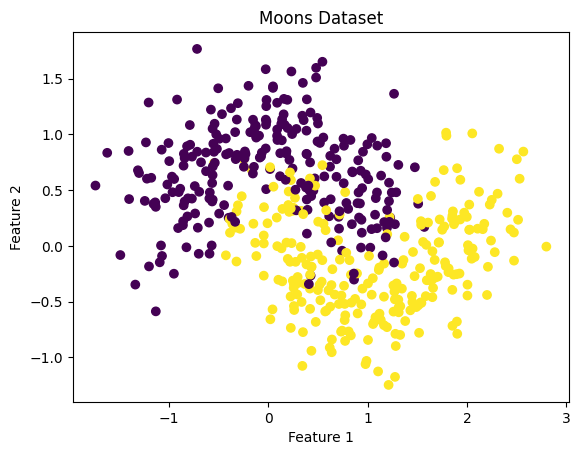

In [ ]:
plt.scatter(x[:,0],x[:,1],c=y)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Moons Dataset")
plt.show()

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42,stratify=y)
print(len(x_train))
print(len(x_test))

350
150


In [ ]:
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [ ]:
model_big_check_validation = Sequential([tf.keras.layers.Input(shape=(2,)),
                                         tf.keras.layers.Dense(256, activation="relu"),
                                         tf.keras.layers.Dense(256, activation="relu"),
                                         tf.keras.layers.Dense(256, activation="relu"),
                                         tf.keras.layers.Dense(256, activation="relu"),
                                         tf.keras.layers.Dense(1, activation="sigmoid")
                                         ])

model_big_check_validation.compile(optimizer="adam",
                                   loss="binary_crossentropy",
                                   metrics=['accuracy']
                                   )

model_big_check_validation.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 198,401 (775.00 KB)

 Trainable params: 198,401 (775.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_big_check_validation_history = model_big_check_validation.fit(x_train_scaled,
                                                                    y_train,
                                                                    #validation_data=(x_test_scaled,y_test),
                                                                    validation_split=0.2,
                                                                    epochs=200,
                                                                    batch_size=16,
                                                                    verbose=1
                                                                    )

Epoch 1/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 12s 341ms/step - accuracy: 0.8464 - loss: 0.4143 - val_accuracy: 0.8000 - val_loss: 0.5255
Epoch 2/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8571 - loss: 0.3492 - val_accuracy: 0.8143 - val_loss: 0.3879
Epoch 3/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8643 - loss: 0.2968 - val_accuracy: 0.8000 - val_loss: 0.3799
Epoch 4/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8714 - loss: 0.2893 - val_accuracy: 0.8000 - val_loss: 0.3541
Epoch 5/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8750 - loss: 0.2681 - val_accuracy: 0.8143 - val_loss: 0.3535
Epoch 6/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8786 - loss: 0.2563 - val_accuracy: 0.8143 - val_loss: 0.3357
Epoch 7/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8929 - loss: 0.2418 - val_accuracy: 0.8429 - val_loss: 0.3184
Epoch 8/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8964 - loss: 0.2317 - val_accuracy: 

In [ ]:
train_loss, train_acc, = model_big_check_validation.evaluate(x_train_scaled, y_train)
test_loss, test_acc = model_big_check_validation.evaluate(x_test_scaled, y_test)
val_loss = model_big_check_validation_history.history['val_loss'][-1]
val_acc = model_big_check_validation_history.history['val_accuracy'][-1]
print("model_big_check_validation Train Loss : ", train_loss)
print("model_big_check_validation Train Accuracy : ", train_acc)
print("model_big_check_validation Validation Loss : ", val_loss)
print("model_big_check_validation Validation Accuracy : ", val_acc)
print("model_big_check_validation Test Loss : ", test_loss)
print("model_big_check_validation Test Accuracy : ", test_acc)

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9486 - loss: 0.1999
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.8667 - loss: 0.8064
model_big_check_validation Train Loss :  0.19987331330776215
model_big_check_validation Train Accuracy :  0.9485714435577393
model_big_check_validation Validation Loss :  0.7821971774101257
model_big_check_validation Validation Accuracy :  0.8571428656578064
model_big_check_validation Test Loss :  0.8063820004463196
model_big_check_validation Test Accuracy :  0.8666666746139526


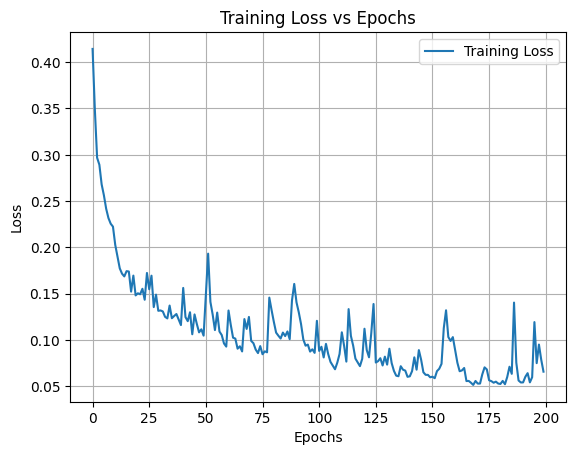

In [ ]:
plt.plot(model_big_check_validation_history.history["loss"], label="Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

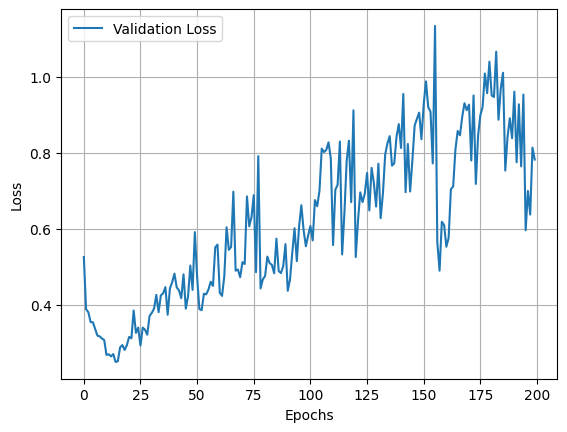

In [ ]:
plt.plot(model_big_check_validation_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

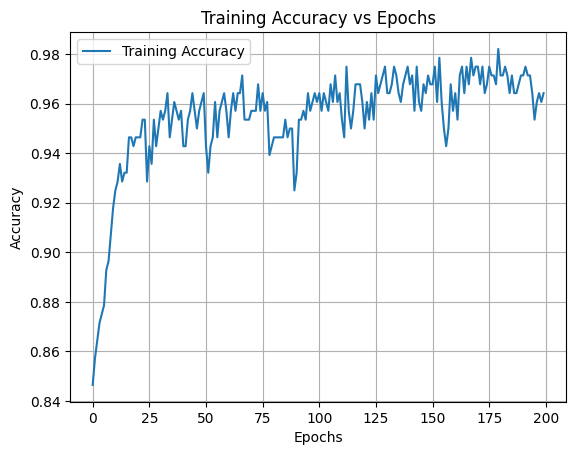

In [ ]:
plt.plot(model_big_check_validation_history.history["accuracy"], label="Training Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training Accuracy vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

##EARLY STOPPING

**EARLY STOPPING**

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor="val_loss",patience=20,restore_best_weights=True)

In [ ]:
model_big_check_validation_history = model_big_check_validation.fit(x_train_scaled,
                                                                    y_train,
                                                                    #validation_data=(x_test_scaled,y_test),
                                                                    validation_split=0.2,
                                                                    epochs=200,
                                                                    batch_size=16,
                                                                    callbacks=[early_stopping],
                                                                    verbose=1
                                                                    )

Epoch 1/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9679 - loss: 0.0742 - val_accuracy: 0.8429 - val_loss: 0.8666
Epoch 2/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9643 - loss: 0.0783 - val_accuracy: 0.8571 - val_loss: 0.7625
Epoch 3/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9500 - loss: 0.2542 - val_accuracy: 0.8429 - val_loss: 0.6579
Epoch 4/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9571 - loss: 0.0956 - val_accuracy: 0.8714 - val_loss: 0.6386
Epoch 5/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9571 - loss: 0.0794 - val_accuracy: 0.8571 - val_loss: 0.5595
Epoch 6/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9714 - loss: 0.0630 - val_accuracy: 0.8571 - val_loss: 0.7332
Epoch 7/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9714 - loss: 0.0571 - val_accuracy: 0.8429 - val_loss: 0.7207
Epoch 8/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9750 - loss: 0.0540 - val_accuracy: 0.8429 - 

In [ ]:
train_loss, train_acc, = model_big_check_validation.evaluate(x_train_scaled, y_train)
test_loss, test_acc = model_big_check_validation.evaluate(x_test_scaled, y_test)
val_loss = model_big_check_validation_history.history['val_loss'][-1]
val_acc = model_big_check_validation_history.history['val_accuracy'][-1]
print("model_big_check_validation Train Loss : ", train_loss)
print("model_big_check_validation Train Accuracy : ", train_acc)
print("model_big_check_validation Validation Loss : ", val_loss)
print("model_big_check_validation Validation Accuracy : ", val_acc)
print("model_big_check_validation Test Loss : ", test_loss)
print("model_big_check_validation Test Accuracy : ", test_acc)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9486 - loss: 0.1601 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8933 - loss: 0.5951 
model_big_check_validation Train Loss :  0.1601421982049942
model_big_check_validation Train Accuracy :  0.9485714435577393
model_big_check_validation Validation Loss :  0.969344437122345
model_big_check_validation Validation Accuracy :  0.8428571224212646
model_big_check_validation Test Loss :  0.5950811505317688
model_big_check_validation Test Accuracy :  0.8933333158493042


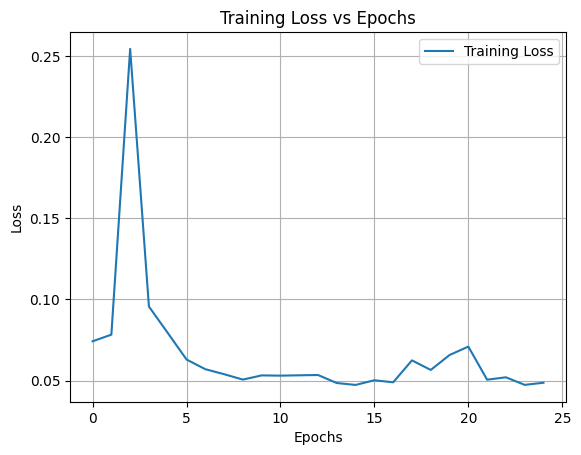

In [ ]:
plt.plot(model_big_check_validation_history.history["loss"], label="Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

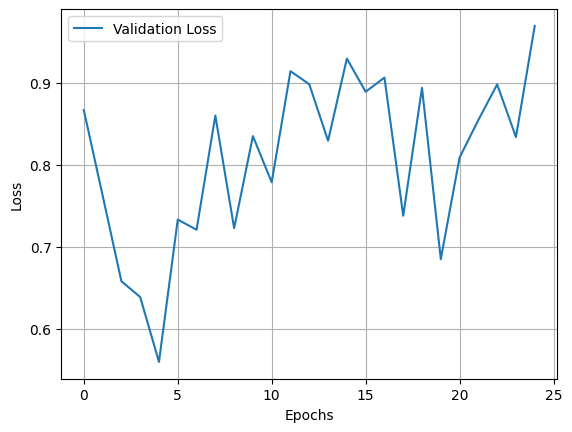

In [ ]:
plt.plot(model_big_check_validation_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

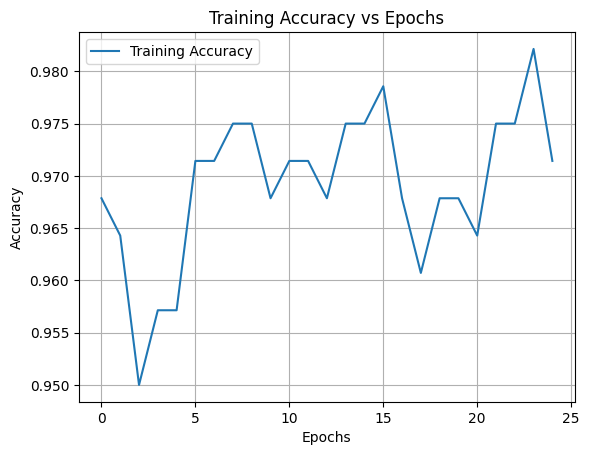

In [ ]:
plt.plot(model_big_check_validation_history.history["accuracy"], label="Training Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training Accuracy vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
model_big_dropout_check_validation = Sequential([tf.keras.layers.Input(shape=(2,)),
                                         tf.keras.layers.Dense(256, activation="relu"),
                                         Dropout(0.4),
                                         tf.keras.layers.Dense(256, activation="relu"),
                                         Dropout(0.4),
                                         tf.keras.layers.Dense(256, activation="relu"),
                                         Dropout(0.4),
                                         tf.keras.layers.Dense(256, activation="relu"),
                                         Dropout(0.4),
                                         tf.keras.layers.Dense(1, activation="sigmoid")
                                         ])

model_big_dropout_check_validation.compile(optimizer="adam",
                                   loss="binary_crossentropy",
                                   metrics=['accuracy']
                                   )

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor="val_loss",patience=20,restore_best_weights=True)
model_big_dropout_check_validation_history =model_big_dropout_check_validation.fit(x_train_scaled,
                                                                    y_train,
                                                                    #validation_data=(x_test_scaled,y_test),
                                                                    validation_split=0.2,
                                                                    epochs=200,
                                                                    batch_size=16,
                                                                    callbacks=[early_stopping],
                                                                    verbose=1
                                                                    )

Epoch 1/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 6s 157ms/step - accuracy: 0.7571 - loss: 0.5542 - val_accuracy: 0.8000 - val_loss: 0.3863
Epoch 2/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8464 - loss: 0.3291 - val_accuracy: 0.8000 - val_loss: 0.4479
Epoch 3/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8571 - loss: 0.3244 - val_accuracy: 0.8000 - val_loss: 0.3834
Epoch 4/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8536 - loss: 0.2984 - val_accuracy: 0.8000 - val_loss: 0.3904
Epoch 5/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8607 - loss: 0.3118 - val_accuracy: 0.8000 - val_loss: 0.3756
Epoch 6/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8607 - loss: 0.3131 - val_accuracy: 0.8000 - val_loss: 0.3673
Epoch 7/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8643 - loss: 0.2925 - val_accuracy: 0.8000 - val_loss: 0.3601
Epoch 8/200
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8643 - loss: 0.2789 - val_accuracy: 0.8000 -

In [ ]:
train_loss, train_acc, = model_big_dropout_check_validation.evaluate(x_train_scaled, y_train)
test_loss, test_acc = model_big_dropout_check_validation.evaluate(x_test_scaled, y_test)
val_loss = model_big_dropout_check_validation_history.history['val_loss'][-1]
val_acc = model_big_dropout_check_validation_history.history['val_accuracy'][-1]
print("model_big_dropout_check_validation Train Loss : ", train_loss)
print("model_big_dropout_check_validation Train Accuracy : ", train_acc)
print("model_big_dropout_check_validation Validation Loss : ", val_loss)
print("model_big_dropout_check_validation Validation Accuracy : ", val_acc)
print("model_big_dropout_check_validation Test Loss : ", test_loss)
print("model_big_dropout_check_validation Test Accuracy : ", test_acc)

11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.9343 - loss: 0.1888
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.9133 - loss: 0.1977
model_big_dropout_check_validation Train Loss :  0.188792884349823
model_big_dropout_check_validation Train Accuracy :  0.9342857003211975
model_big_dropout_check_validation Validation Loss :  0.31693458557128906
model_big_dropout_check_validation Validation Accuracy :  0.8999999761581421
model_big_dropout_check_validation Test Loss :  0.19767025113105774
model_big_dropout_check_validation Test Accuracy :  0.9133333563804626


**Dropout**


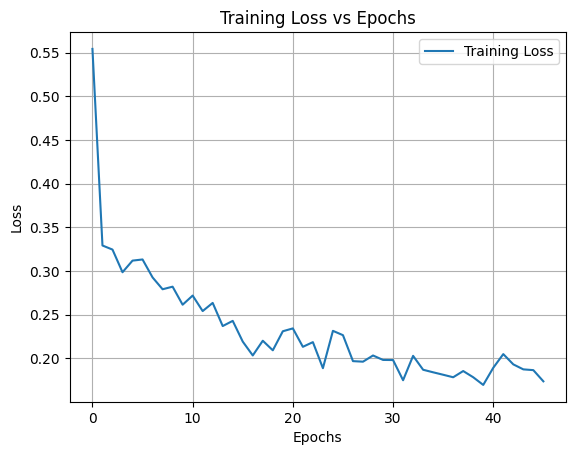

In [ ]:
plt.plot(model_big_dropout_check_validation_history.history["loss"], label="Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

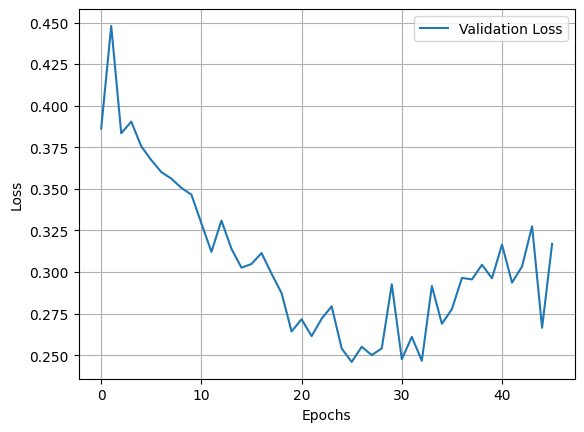

In [ ]:
plt.plot(model_big_dropout_check_validation_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

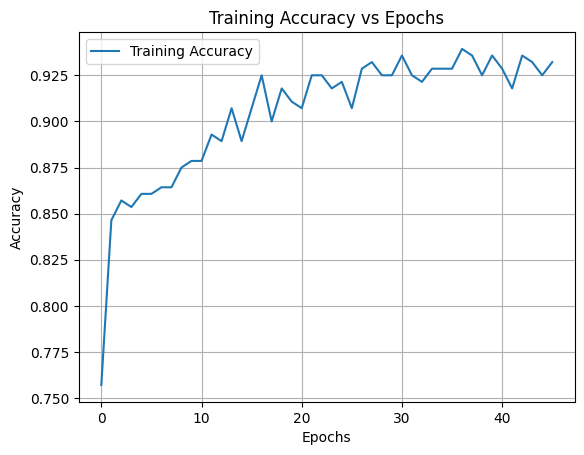

In [ ]:
plt.plot(model_big_dropout_check_validation_history.history["accuracy"], label="Training Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training Accuracy vs Epochs")
plt.legend()
plt.grid(True)
plt.show()

**#Lab 03-05-2026 - Data Augmentation**


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout, Flatten, Dense
from tensorflow.keras.layers import RandomRotation, RandomZoom, RandomTranslation
from tensorflow.keras.datasets import fashion_mnist

In [ ]:
tf.keras.utils.set_random_seed(42)
(X_train,y_train),(X_test,y_test)= fashion_mnist.load_data()
print("X_train shape : ", X_train.shape)
print("y_train shape : ", y_train.shape)
print("X_test shape : ", X_test.shape)
print("y_test shape : ", y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
X_train shape :  (60000, 28, 28)
y_train shape :  (60000,)
X_test shape :  (10000, 28, 28)
y_test shape :  (10000,)


In [ ]:
Class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

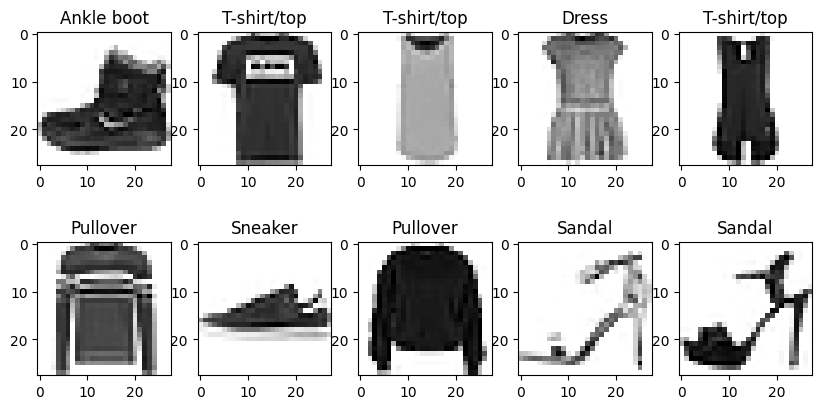

In [ ]:
plt.figure(figsize=(10,5))
for i in range(10):
  plt.subplot(2,5,i+1)
  plt.imshow(X_train[i], cmap=plt.cm.binary)
  plt.title(Class_names[y_train[i]])


In [ ]:
X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)
print("X_train shape : ", X_train.shape)
print("X_test shape : ", X_test.shape)

X_train shape :  (60000, 28, 28, 1)
X_test shape :  (10000, 28, 28, 1)


In [ ]:
X_valid = X_train[:5000]
y_valid = y_train[:5000]
X_train_small = X_train[5000:15000]
y_train_small = y_train[5000:15000]

print("X_valid shape : ", X_valid.shape)
print("y_valid shape : ", y_valid.shape)
print("X_train_small shape : ", X_train_small.shape)

X_valid shape :  (5000, 28, 28, 1)
y_valid shape :  (5000,)
X_train_small shape :  (10000, 28, 28, 1)


In [ ]:
Model_mnist_Without_aug = Sequential([
    Flatten(input_shape=[28,28,1]),
    Dense(256, activation="relu"),
    Dropout(0.3),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(10, activation="softmax")
])


Model_mnist_Without_aug.compile(optimizer="adam",
                                loss="sparse_categorical_crossentropy",
                                metrics=["accuracy"]
                                )

Model_mnist_Without_aug.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
Model_mnist_Without_aug_history = Model_mnist_Without_aug.fit(X_train_small, y_train_small,validation_split=0.2, epochs=20, batch_size=64, verbose=1)

Epoch 1/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.4927 - loss: 17.4816 - val_accuracy: 0.6145 - val_loss: 1.4450
Epoch 2/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.4992 - loss: 2.0448 - val_accuracy: 0.5860 - val_loss: 1.4298
Epoch 3/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5184 - loss: 1.6404 - val_accuracy: 0.5995 - val_loss: 1.1896
Epoch 4/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5200 - loss: 1.5460 - val_accuracy: 0.6115 - val_loss: 1.1941
Epoch 5/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5269 - loss: 1.5186 - val_accuracy: 0.5980 - val_loss: 1.1870
Epoch 6/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5366 - loss: 1.4157 - val_accuracy: 0.6185 - val_loss: 1.1434
Epoch 7/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5541 - loss: 1.3914 - val_accuracy: 0.6515 - val_loss: 1.0754
Epoch 8/20
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5502 - loss: 1.3262 - val_accuracy:

In [ ]:
train_loss, train_acc = Model_mnist_Without_aug.evaluate(X_train_small, y_train_small)
test_loss, test_acc = Model_mnist_Without_aug.evaluate(X_valid, y_valid)
print("Model_mnist_Without_aug Train Loss : ", train_loss)
print("Model_mnist_Without_aug Train Accuracy : ", train_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7282 - loss: 0.6916
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7320 - loss: 0.7767
Model_mnist_Without_aug Train Loss :  0.6915615797042847
Model_mnist_Without_aug Train Accuracy :  0.7282000184059143


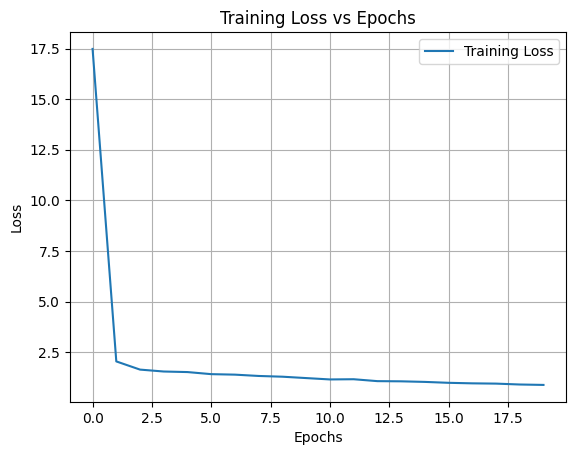

In [ ]:
plt.plot(Model_mnist_Without_aug_history.history["loss"], label="Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss vs Epochs")
plt.legend()
plt.grid(True)

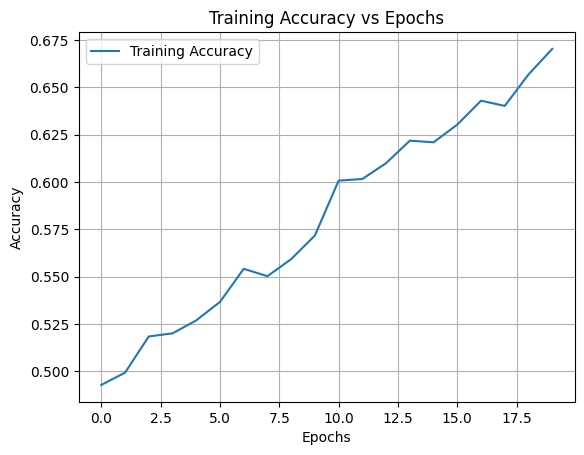

In [ ]:
plt.plot(Model_mnist_Without_aug_history.history["accuracy"], label="Training Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training Accuracy vs Epochs")
plt.legend()
plt.grid(True)

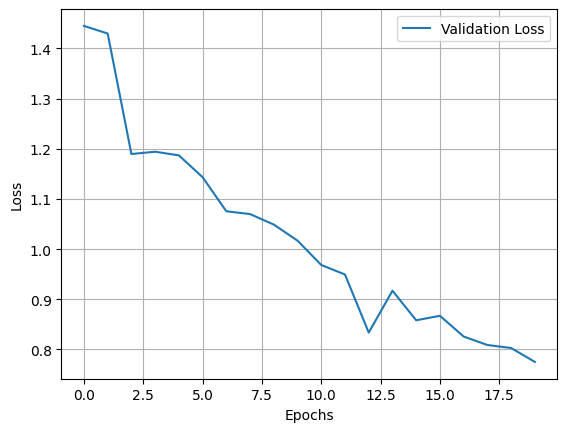

In [ ]:
plt.plot(Model_mnist_Without_aug_history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

##Augmented Data creation


In [ ]:
data_augmentation=Sequential([
    RandomRotation(0.1), #Slightly rotates the image
    RandomZoom(0.1), #Slightly Zooms the image
    RandomTranslation(0.1,0.1) #slightly shift the image
])

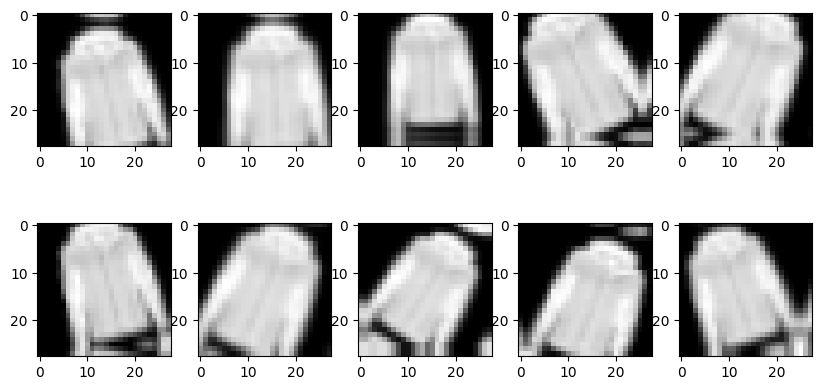

In [ ]:
smaple_image=X_train_small[0] #the first image

plt.figure(figsize=(10,5))

for i in range(10):
  augmented_image=data_augmentation(
      tf.expand_dims(smaple_image,axis=0),   #28X28X1,
      training=True)
  plt.subplot(2,5,i+1)
  plt.imshow(augmented_image[0].numpy().squeeze(), cmap="gray")
plt.show()


In [ ]:
Model_Mnist_With_Aug=Sequential([
    data_augmentation,
    Flatten(input_shape=[28,28,1]),
    Dense(256,activation='relu'),
    Dropout(0.3),
    Dense(128,activation='relu'),
    Dropout(0.3),
    Dense(10,activation='softmax'),


])

Model_Mnist_With_Aug.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
history_Model_Mnist_With_Aug=Model_Mnist_With_Aug.fit(
    X_train_small,
    y_train_small,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.2650 - loss: 18.2140 - val_accuracy: 0.3230 - val_loss: 2.2212
Epoch 2/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.2201 - loss: 2.2951 - val_accuracy: 0.3165 - val_loss: 1.9649
Epoch 3/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - accuracy: 0.2210 - loss: 2.1856 - val_accuracy: 0.3125 - val_loss: 1.9031
Epoch 4/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 8s 60ms/step - accuracy: 0.2280 - loss: 2.1664 - val_accuracy: 0.3360 - val_loss: 1.9450
Epoch 5/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.2321 - loss: 2.1491 - val_accuracy: 0.3125 - val_loss: 1.9636
Epoch 6/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.2291 - loss: 2.1266 - val_accuracy: 0.3145 - val_loss: 2.2008
Epoch 7/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.2489 - loss: 2.1089 - val_accuracy: 0.3975 - val_loss: 1.8068
Epoch 8/30
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.2355 - loss: 2.1037 - val_acc

In [ ]:
train_loss_1, train_acc_1=Model_Mnist_With_Aug.evaluate(X_train_small,y_train_small, verbose=0)
test_loss_1,test_acc_1=Model_Mnist_With_Aug.evaluate(X_valid,y_valid, verbose=0)
print("Train Accuracy:",train_acc_1)
print("Test Accuracy:",test_acc_1)


Train Accuracy: 0.6014999747276306
Test Accuracy: 0.6133999824523926


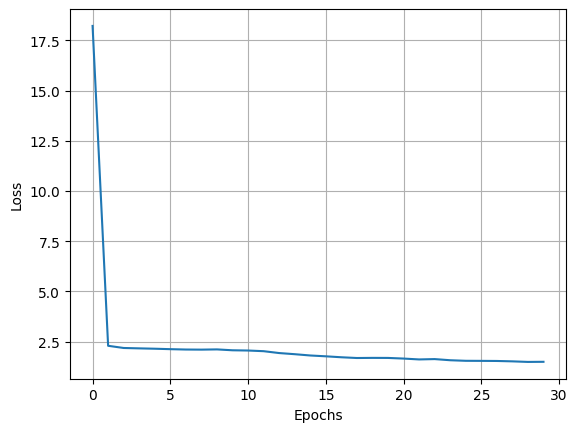

In [ ]:
plt.plot(history_Model_Mnist_With_Aug.history['loss'], label='Training Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


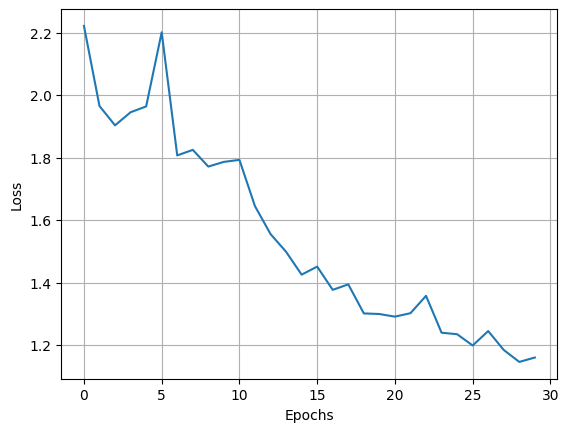

In [ ]:
plt.plot(history_Model_Mnist_With_Aug.history['val_loss'], label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


#**Lab 03-05-2026 Gradient Problem**

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.layers import Dropout, Flatten
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.initializers import RandomNormal, HeNormal


In [ ]:
tf.keras.utils.set_random_seed(42)
X,y=make_moons(n_samples=500,noise=0.3,random_state=42)
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3, random_state=42, stratify=y)

print(X_train.shape,y_train.shape)
print(X_test.shape,y_test.shape)


(350, 2) (350,)
(150, 2) (150,)


In [ ]:
scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [ ]:
def get_gradient_table(model,X_batch,y_batch):
  X_batch=tf.convert_to_tensor(X_batch,dtype=tf.float32)
  y_batch=tf.convert_to_tensor(y_batch.reshape(-1,1),dtype=tf.float32)

  loss_function=tf.keras.losses.BinaryCrossentropy()

  with tf.GradientTape() as tape:
    y_pred=model(X_batch,training=True)
    loss=loss_function(y_batch,y_pred)

  gradients=tape.gradient(loss,model.trainable_variables)

  rows=[]
  for variable,gradient in zip(model.trainable_variables,gradients):
    rows.append({
        "Variable Name":variable.name,
        "Varibale Shape":variable.shape,
        "Gradient Norm":float(tf.norm(gradient).numpy()),
        "Weight/Bias Norm":float(tf.norm(variable).numpy())
    })

  return pd.DataFrame(rows)

In [ ]:
def plot_gradient_norm(gradient_table,title):
  plt.figure(figsize=(10,5))
  plt.semilogy(
      range(1,len(gradient_table)+1), #X axis
      gradient_table["Gradient Norm"], # Y axis
      marker="o"
  )
  plt.xlabel("Trainable Variable Number")
  plt.ylabel("Gradient Norm")
  plt.title(title)
  plt.grid(True)
  plt.show()


In [ ]:
model_shallow=Sequential(
    [
        Input(shape=(2,)),
        Dense(8,activation="relu"),
        Dense(1,activation="sigmoid")
    ]
)

model_shallow.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=['accuracy']
)
model_shallow.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            24 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33 (132.00 B)

 Trainable params: 33 (132.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
gradient_table_shallow = get_gradient_table(
    model=model_shallow,
    X_batch=X_train_scaled,
    y_batch=y_train
)
gradient_table_shallow

,Variable Name,Varibale Shape,Gradient Norm,Weight/Bias Norm
0,kernel,"(2, 8)",0.222692,1.826693
1,bias,(8),0.126950,0.000000
2,kernel,"(8, 1)",0.368400,1.313624
3,bias,(1),0.162960,0.000000


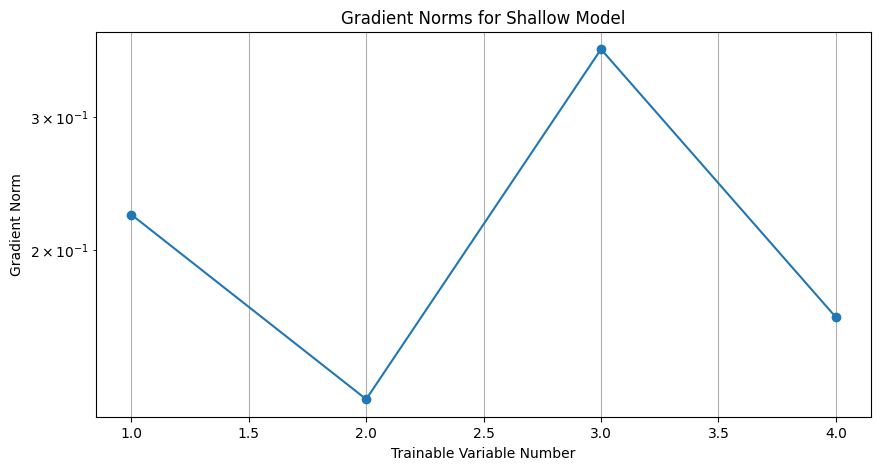

In [ ]:
plot_gradient_norm(gradient_table_shallow, "Gradient Norms for Shallow Model")

##Vanishing Gradient Problem

In [ ]:
from tensorflow.keras.initializers import RandomNormal
model_vanishing = Sequential([
    Input(shape=(2,)),
    Dense(16, activation="sigmoid",kernel_initializer=RandomNormal(stddev=0.01)),
    Dense(16, activation="sigmoid",kernel_initializer=RandomNormal(stddev=0.01)),
    Dense(16, activation="sigmoid",kernel_initializer=RandomNormal(stddev=0.01)),
    Dense(16, activation="sigmoid",kernel_initializer=RandomNormal(stddev=0.01)),
    Dense(16, activation="sigmoid",kernel_initializer=RandomNormal(stddev=0.01)),
    Dense(16, activation="sigmoid",kernel_initializer=RandomNormal(stddev=0.01)),
    Dense(16, activation="sigmoid",kernel_initializer=RandomNormal(stddev=0.01)),
    Dense(16, activation="sigmoid",kernel_initializer=RandomNormal(stddev=0.01)),
    Dense(16, activation="sigmoid",kernel_initializer=RandomNormal(stddev=0.01)),
    Dense(1,activation='sigmoid')

])

model_vanishing.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,241 (8.75 KB)

 Trainable params: 2,241 (8.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_vanishing.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=['accuracy']
)

model_vanishing.summary(
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,241 (8.75 KB)

 Trainable params: 2,241 (8.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
gradient_table_vanishing = get_gradient_table(
    model_vanishing,
    X_train_scaled,
    y_train
)

gradient_table_vanishing

,Variable Name,Varibale Shape,Gradient Norm,Weight/Bias Norm
0,kernel,"(2, 16)",7.816191e-18,0.058428
1,bias,(16),4.077938e-18,0.000000
2,kernel,"(16, 16)",7.190641e-16,0.169590
3,bias,(16),3.587515e-16,0.000000
4,kernel,"(16, 16)",5.054329e-14,0.166141
5,bias,(16),2.525510e-14,0.000000
6,kernel,"(16, 16)",5.482856e-12,0.159787
7,bias,(16),2.746310e-12,0.000000
8,kernel,"(16, 16)",7.660686e-10,0.158155
9,bias,(16),3.821099e-10,0.000000


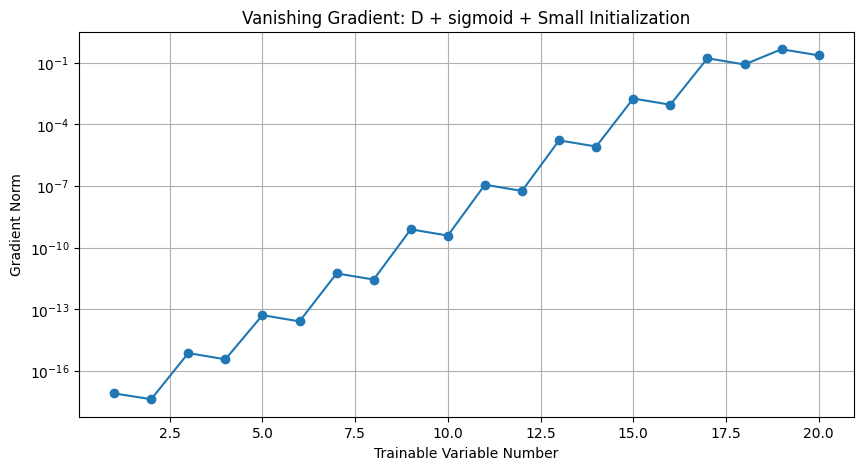

In [ ]:
plot_gradient_norm(
    gradient_table_vanishing,
    "Vanishing Gradient: D + sigmoid + Small Initialization"
)

##Exploding Gradient Problem

In [ ]:
model_exploding = Sequential([
    Input(shape=(2,)),
    Dense(16, activation='relu',kernel_initializer=RandomNormal(stddev=2.0)),
    Dense(16, activation='relu',kernel_initializer=RandomNormal(stddev=2.0)),
    Dense(16, activation='relu',kernel_initializer=RandomNormal(stddev=2.0)),
    Dense(16, activation='relu',kernel_initializer=RandomNormal(stddev=2.0)),
    Dense(16, activation='relu',kernel_initializer=RandomNormal(stddev=2.0)),
    Dense(16, activation='relu',kernel_initializer=RandomNormal(stddev=2.0)),
    Dense(16, activation='relu',kernel_initializer=RandomNormal(stddev=2.0)),
    Dense(16, activation='relu',kernel_initializer=RandomNormal(stddev=2.0)),
    Dense(1, activation='sigmoid',kernel_initializer=RandomNormal(stddev=2.0))
])

model_exploding.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.1),
    loss='binary_crossentropy',
    metrics=['accuracy']

)

model_exploding.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,969 (7.69 KB)

 Trainable params: 1,969 (7.69 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
gradient_table_exploding = get_gradient_table(
    model_exploding,
    X_train_scaled,
    y_train
)

gradient_table_exploding

,Variable Name,Varibale Shape,Gradient Norm,Weight/Bias Norm
0,kernel,"(2, 16)",104679.703125,10.749317
1,bias,(16),83965.210938,0.000000
2,kernel,"(16, 16)",118626.718750,30.972692
3,bias,(16),16786.724609,0.000000
4,kernel,"(16, 16)",84345.054688,33.132172
5,bias,(16),3403.220947,0.000000
6,kernel,"(16, 16)",97909.343750,29.858858
7,bias,(16),718.113403,0.000000
8,kernel,"(16, 16)",103691.484375,32.270149
9,bias,(16),89.994881,0.000000


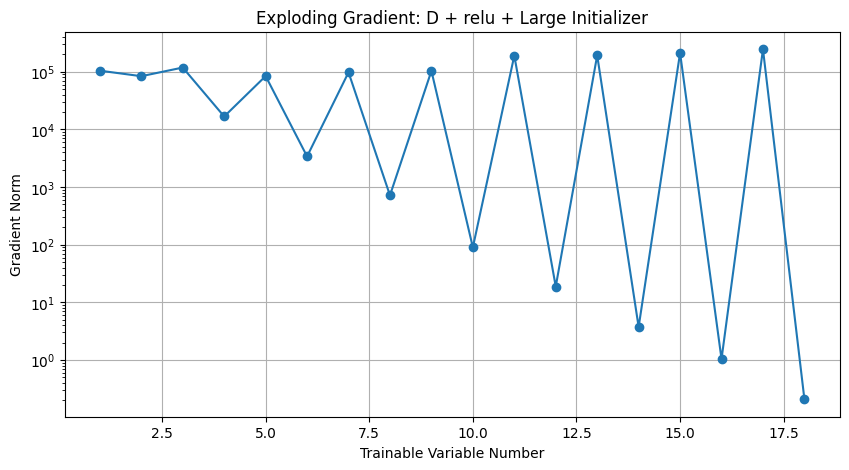

In [ ]:
plot_gradient_norm(
    gradient_table_exploding,
    "Exploding Gradient: D + relu + Large Initializer"
)

##Good Gradient Model

In [ ]:
model_stable = Sequential([
  Input(shape=(2,)),
  Dense(16,activation='relu',kernel_initializer=HeNormal()),  #tries to initialize weight optimal to model based on input layer
  Dense(16,activation='relu',kernel_initializer=HeNormal()),
  Dense(16,activation='relu',kernel_initializer=HeNormal()),
  Dense(16,activation='relu',kernel_initializer=HeNormal()),
  Dense(16,activation='relu',kernel_initializer=HeNormal() ),
  Dense(16,activation='relu',kernel_initializer=HeNormal() ),
  Dense(16,activation='relu',kernel_initializer=HeNormal() ),
  Dense(16,activation='relu',kernel_initializer=HeNormal() ),
  Dense(1,activation='sigmoid')
])

model_stable.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']

)

model_stable.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,969 (7.69 KB)

 Trainable params: 1,969 (7.69 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
gradient_table_stable = get_gradient_table(
    model_stable,
    X_train_scaled,
    y_train
)

gradient_table_stable

,Variable Name,Varibale Shape,Gradient Norm,Weight/Bias Norm
0,kernel,"(2, 16)",0.213419,5.337816
1,bias,(16),0.132185,0.000000
2,kernel,"(16, 16)",0.540080,5.768145
3,bias,(16),0.129582,0.000000
4,kernel,"(16, 16)",0.557310,5.799547
5,bias,(16),0.151421,0.000000
6,kernel,"(16, 16)",0.576037,5.433398
7,bias,(16),0.185369,0.000000
8,kernel,"(16, 16)",0.663865,5.597531
9,bias,(16),0.236594,0.000000


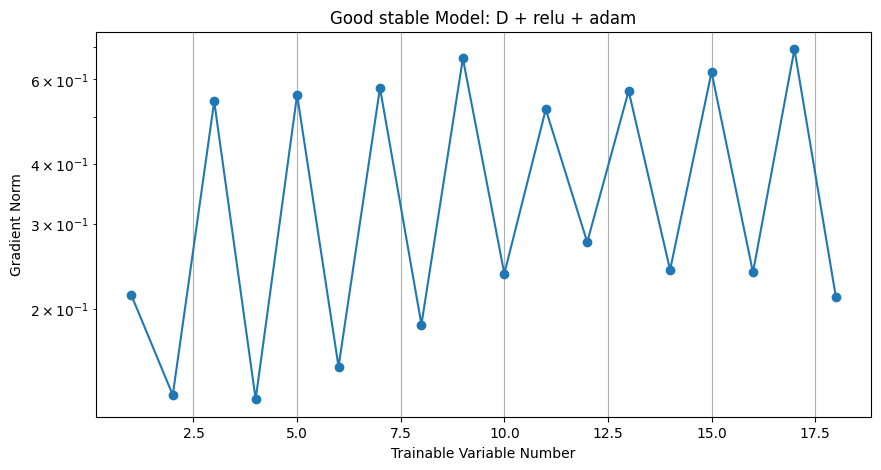

In [ ]:
plot_gradient_norm(
    gradient_table_stable,
    "Good stable Model: D + relu + adam"
)

##Lets Train our Models


In [ ]:
history_model_shallow = model_shallow.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_test_scaled,y_test),
    epochs=100,
    batch_size=16,
    verbose=0
)

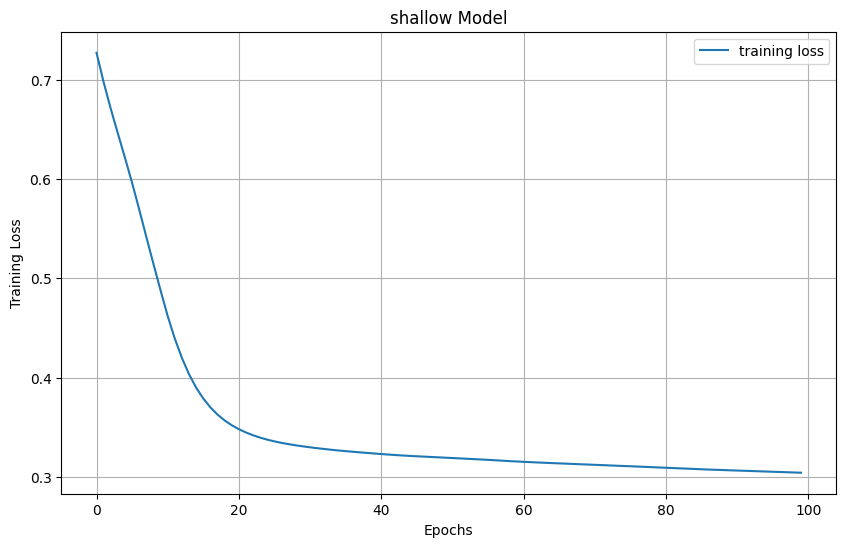

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(history_model_shallow.history['loss'],label='training loss')
plt.xlabel('Epochs')
plt.ylabel('Training Loss')
plt.title("shallow Model")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
hitory_model_vanishing = model_vanishing.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_test_scaled,y_test),
    epochs=100,
    batch_size=16,
    verbose=0
)


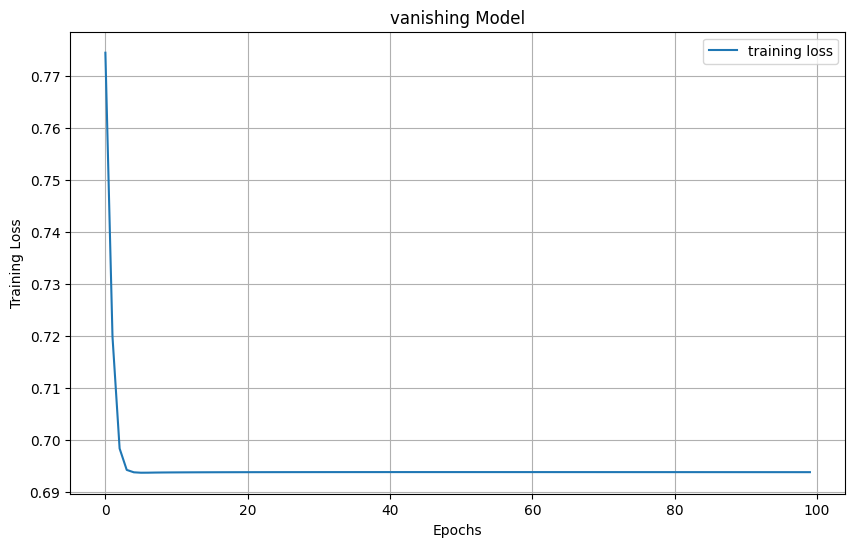

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(hitory_model_vanishing.history['loss'],label='training loss')
plt.xlabel('Epochs')
plt.ylabel('Training Loss')
plt.title("vanishing Model")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
hitory_model_exploding = model_exploding.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_test_scaled,y_test),
    epochs=100,
    batch_size=16,
    verbose=0
)


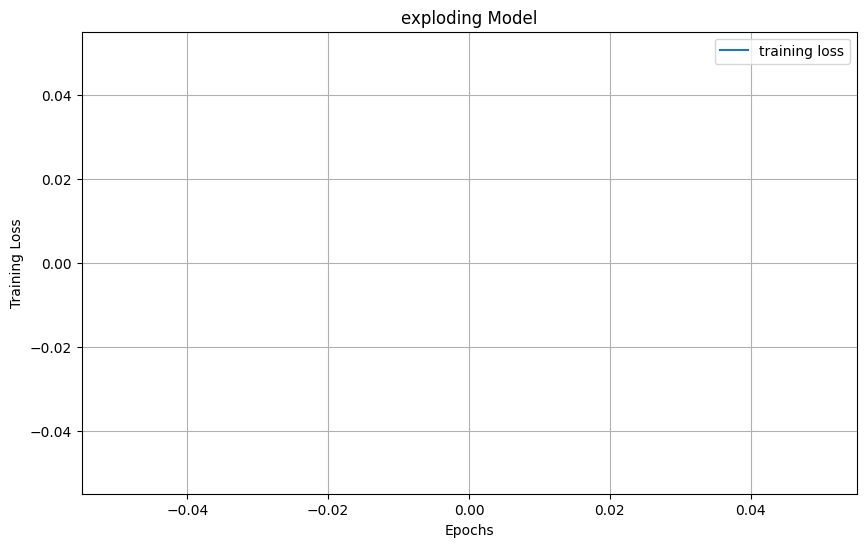

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(hitory_model_exploding.history['loss'],label='training loss')
plt.xlabel('Epochs')
plt.ylabel('Training Loss')
plt.title("exploding Model")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
hitory_model_good = model_stable.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_test_scaled,y_test),
    epochs=100,
    batch_size=16,
    verbose=0
)


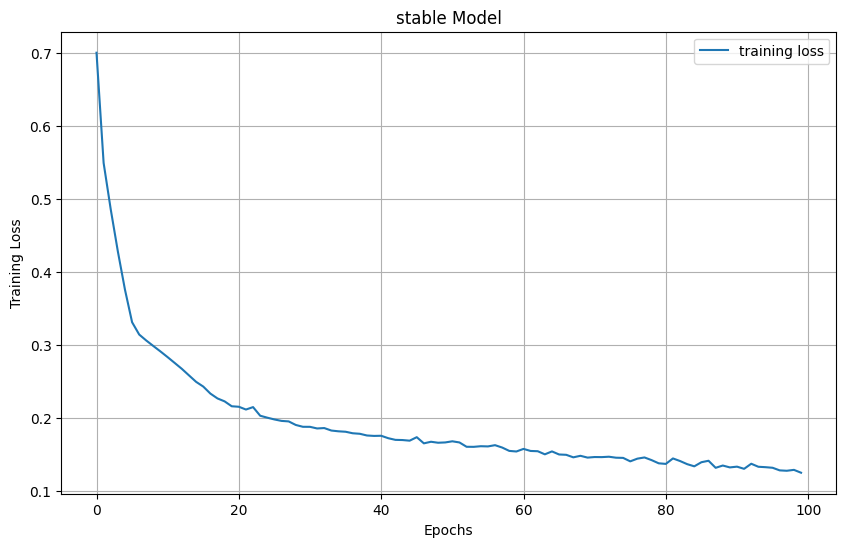

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(hitory_model_good.history['loss'],label='training loss')
plt.xlabel('Epochs')
plt.ylabel('Training Loss')
plt.title("stable Model")
plt.legend()
plt.grid(True)
plt.show()


#**Lab 05-06-2026 Normalization**

##BreastCancer Dataset with MInMax Scaling Normalization

In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

In [ ]:
# Load dataset
data = load_breast_cancer()

In [ ]:
X = data.data
y = data.target

In [ ]:
print("Before Normalization")
print(X[:5])

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Before Normalization
[[1.799e+01 1.038e+01 1.228e+02 1.001e+03 1.184e-01 2.776e-01 3.001e-01
  1.471e-01 2.419e-01 7.871e-02 1.095e+00 9.053e-01 8.589e+00 1.534e+02
  6.399e-03 4.904e-02 5.373e-02 1.587e-02 3.003e-02 6.193e-03 2.538e+01
  1.733e+01 1.846e+02 2.019e+03 1.622e-01 6.656e-01 7.119e-01 2.654e-01
  4.601e-01 1.189e-01]
 [2.057e+01 1.777e+01 1.329e+02 1.326e+03 8.474e-02 7.864e-02 8.690e-02
  7.017e-02 1.812e-01 5.667e-02 5.435e-01 7.339e-01 3.398e+00 7.408e+01
  5.225e-03 1.308e-02 1.860e-02 1.340e-02 1.389e-02 3.532e-03 2.499e+01
  2.341e+01 1.588e+02 1.956e+03 1.238e-01 1.866e-01 2.416e-01 1.860e-01
  2.750e-01 8.902e-02]
 [1.969e+01 2.125e+01 1.300e+02 1.203e+03 1.096e-01 1.599e-01 1.974e-01
  1.279e-01 2.069e-01 5.999e-02 7.456e-01 7.869e-01 4.585e+00 9.403e+01
  6.150e-03 4.006e-02 3.832e-02 2.058e-02 2.250e-02 4.571e-03 2.357e+01
  2.553e+01 1.525e+02 1.709e+03 1.444e-01 4.245e-01 4.504e-01 2.430e-01
  3.613e-01 8.758e-02]
 [1.142e+01 2.038e+01 7.758e+01 3.861e+02 1.42

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model = Sequential([
    Input(shape=(30,)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train,      # Original data (NOT normalized)
    y_train,
    epochs=100,
    validation_split=0.2,
    verbose=0
)

In [ ]:
loss, acc = model.evaluate(X_test, y_test)

print("Accuracy without normalization:", acc)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9561 - loss: 0.0930 
Accuracy without normalization: 0.9561403393745422


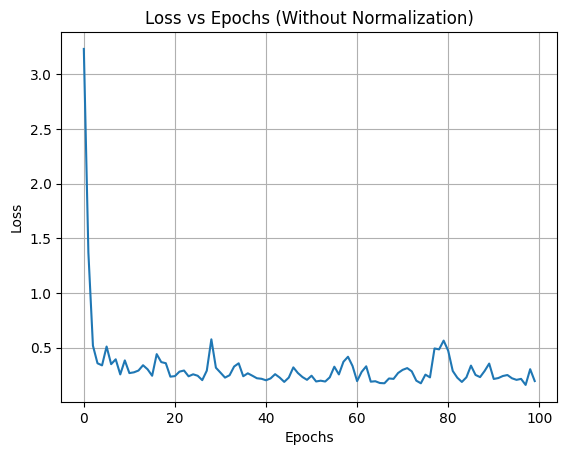

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.title("Loss vs Epochs (Without Normalization)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [ ]:
 #Normalization
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nAfter Normalization")
print(X_train_scaled[:5])


After Normalization
[[0.06552721 0.25769361 0.07732252 0.03436883 0.48722578 0.41750565
  0.73336457 0.21744533 0.50400427 0.64237574 0.07818215 0.18427334
  0.05314988 0.02029892 0.26637658 0.62943491 0.76717172 0.62928585
  0.63623129 0.29933115 0.05964476 0.28331557 0.05597072 0.02508436
  0.523195   0.44938009 1.         0.60137457 0.52493594 0.52950153]
 [0.65620256 0.57017247 0.67420686 0.48940187 0.55493365 0.90343127
  0.58270853 0.74353877 0.65563267 0.50589722 0.18768785 0.08899841
  0.17231306 0.13944393 0.08634463 0.34050831 0.09777778 0.29683652
  0.18847288 0.1520183  0.65791974 0.57196162 0.62025316 0.46283247
  0.52930789 0.80287939 0.54153355 0.9975945  0.49931007 0.62190573]
 [0.07257946 0.14034494 0.08023901 0.0388312  0.22190124 0.23330594
  0.14029991 0.1083499  0.62680192 0.4142797  0.108021   0.42096888
  0.0872167  0.03122537 0.23880749 0.2788476  0.10888889 0.29551051
  0.63529807 0.17022512 0.04868065 0.19216418 0.05642824 0.02146189
  0.18467704 0.15430316 0

In [ ]:
print("Minimum value:", X_train_scaled.min())
print("Maximum value:", X_train_scaled.max())

Minimum value: 0.0
Maximum value: 1.0000000000000002


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input

model_with_norm = Sequential([
    Input(shape=(30,)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_with_norm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_norm = model_with_norm.fit(
    X_train_scaled,
    y_train,
    epochs=100,
    validation_split=0.2,
    verbose=0
)

In [ ]:
loss_norm, acc_norm = model_with_norm.evaluate(
    X_test_scaled,
    y_test
)

print("Accuracy with normalization:", acc_norm)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9737 - loss: 0.0652 
Accuracy with normalization: 0.9736841917037964


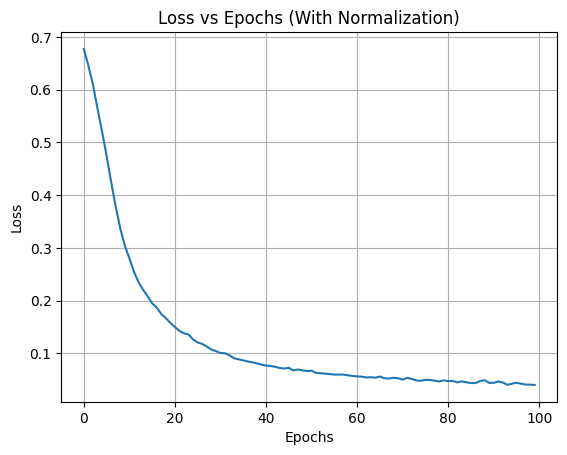

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history_norm.history['loss'])
plt.title("Loss vs Epochs (With Normalization)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

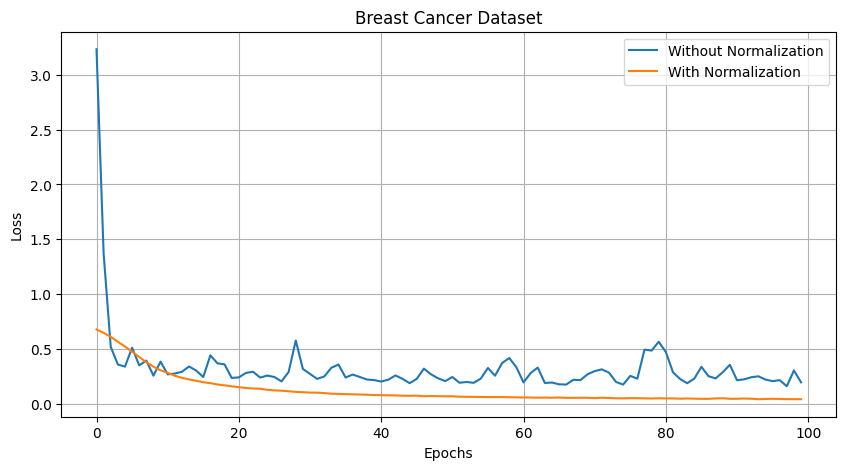

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(history.history['loss'],
         label='Without Normalization')

plt.plot(history_norm.history['loss'],
         label='With Normalization')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Breast Cancer Dataset')
plt.legend()
plt.grid(True)

plt.show()

## 06-05-2026 Batch Normalization

> with layer Normalization using BatchNormalization and Testing with and without Input Normalization



In [ ]:
from tensorflow.keras.layers import BatchNormalization

In [ ]:
##Normalize output of one layer then normalize and give output to next layer as input

In [78]:
model_with_bn_without_inp_norm = Sequential([
    Input(shape=(30,)),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dense(16, activation='relu'),
    BatchNormalization(),
    Dense(1, activation='sigmoid')
])

model_with_bn_without_inp_norm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [79]:
model_with_bn_with_inp_norm = Sequential([
    Input(shape=(30,)),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dense(16, activation='relu'),
    BatchNormalization(),
    Dense(1, activation='sigmoid')
])

model_with_bn_with_inp_norm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [80]:
history_model_with_bn_without_inp_norm = model_with_bn_without_inp_norm.fit(
    X_train,
    y_train,
    epochs=50,
    validation_split=0.2,
    verbose=1

)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 66ms/step - accuracy: 0.7473 - loss: 0.5221 - val_accuracy: 0.4505 - val_loss: 0.7609
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8901 - loss: 0.2895 - val_accuracy: 0.3736 - val_loss: 0.9538
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9038 - loss: 0.2696 - val_accuracy: 0.3846 - val_loss: 0.9331
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9176 - loss: 0.2272 - val_accuracy: 0.3846 - val_loss: 0.9322
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9176 - loss: 0.2235 - val_accuracy: 0.4176 - val_loss: 0.9462
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9203 - loss: 0.2042 - val_accuracy: 0.4615 - val_loss: 0.8006
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9313 - loss: 0.1878 - val_accuracy: 0.5165 - val_loss: 0.6629
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.9176 - loss: 0.1962 - val_accuracy: 0.6703 - val

In [81]:
history_model_with_bn_with_inp_norm = model_with_bn_with_inp_norm.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.6429 - loss: 0.6625 - val_accuracy: 0.5055 - val_loss: 0.6962
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8626 - loss: 0.3962 - val_accuracy: 0.7253 - val_loss: 0.6848
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9011 - loss: 0.3201 - val_accuracy: 0.7143 - val_loss: 0.6701
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9368 - loss: 0.2525 - val_accuracy: 0.7143 - val_loss: 0.6551
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9588 - loss: 0.2182 - val_accuracy: 0.8022 - val_loss: 0.6286
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9780 - loss: 0.1761 - val_accuracy: 0.8022 - val_loss: 0.5999
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9643 - loss: 0.1578 - val_accuracy: 0.8132 - val_loss: 0.5657
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9808 - loss: 0.1445 - val_accuracy: 0.8242 - va

In [85]:
loss_without, acc_without = model_with_bn_without_inp_norm.evaluate(X_test,y_test,verbose=0)
loss_with, acc_with = model_with_bn_with_inp_norm.evaluate(X_test_scaled,y_test,verbose=0)

print("With Normalization without Input Normalization")
print("Test Loss:", loss_without)
print("Test Accuracy:", acc_without)

print("\nWith Normalization with Input Normalization")
print("Test Loss:", loss_with)
print("Test Accuracy:", acc_with)



With Normalization without Input Normalization
Test Loss: 0.16366708278656006
Test Accuracy: 0.9298245906829834

With Normalization with Input Normalization
Test Loss: 0.1245967447757721
Test Accuracy: 0.9561403393745422


#**Lab-06-05-3036 fashion and digit mnist dataset normalization**

In [86]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Flatten
import matplotlib.pyplot as plt
import numpy as np

In [87]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [90]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


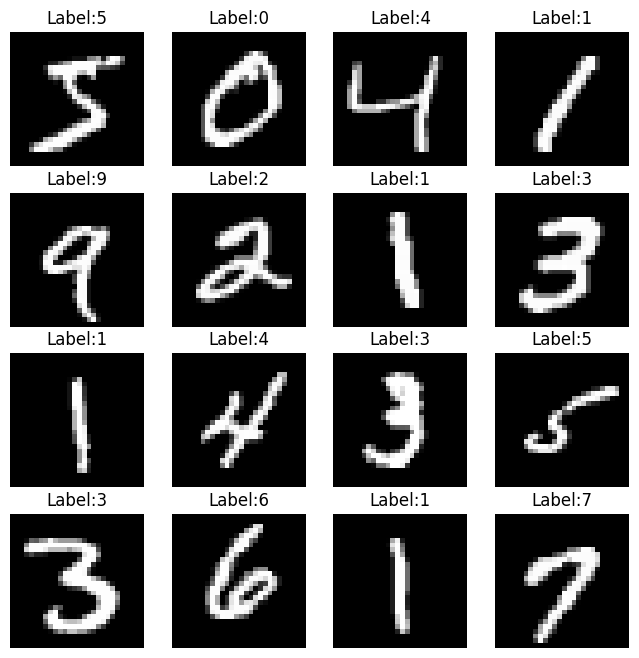

In [99]:
plt.figure(figsize=(8,8))

for i in range(16):
  plt.subplot(4,4,i+1)
  plt.imshow(X_train[i],cmap="grey")
  plt.title("Label:"+ str(y_train[i]))
  plt.axis('off')

In [106]:
print("before Normalization pixel value", X_train[3])


X_train_norm = X_train / 255.0
X_test_norm = X_test / 255.0


print("after Normalization pixel value", X_train_norm[3])


before Normalization pixel value [[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
  124 253 255  63   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0  96
  244 251 253  62   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0 127
  251 251 253  62   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0  

In [107]:
model_digit = Sequential([
    Input(shape=(28,28)),   #Convert 28x28 into 784 feature for each image
    Flatten(),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(10, activation='softmax')
])

model_digit.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [109]:
history_model_digit = model_digit.fit(
    X_train_norm,
    y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1

)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9928 - loss: 0.0263 - val_accuracy: 0.9762 - val_loss: 0.0889
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9949 - loss: 0.0198 - val_accuracy: 0.9783 - val_loss: 0.0864
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9959 - loss: 0.0170 - val_accuracy: 0.9750 - val_loss: 0.0955
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9962 - loss: 0.0146 - val_accuracy: 0.9772 - val_loss: 0.0922
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9970 - loss: 0.0124 - val_accuracy: 0.9785 - val_loss: 0.0915
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9973 - loss: 0.0116 - val_accuracy: 0.9767 - val_loss: 0.0976
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9979 - loss: 0.0092 - val_accuracy: 0.9763 - val_loss: 0.1009
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9978 - loss: 0.0088 - val_accuracy: 0.

In [111]:
loss, acc = history_model_digit.evaluate(X_test_scaled,y_test,verbose=0)

print("\nWith Normalization with Input Normalization")
print("Test Loss:", loss_with)
print("Test Accuracy:", acc_with)



AttributeError: 'History' object has no attribute 'evaluate'

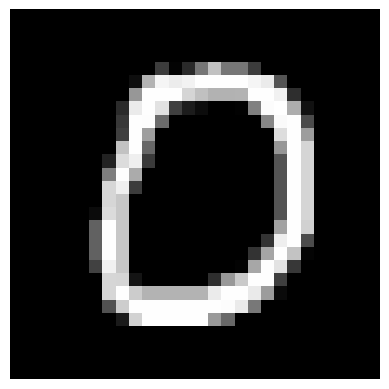

In [112]:
index =10
plt.imshow(X_test[index],cmap="grey")
plt.axis("off")
plt.show()

In [114]:
prediction = model_digit.predict(X_test[index].reshape(1,28,28))
print("Prediction Probabilites: ", prediction)
print("Prediction Value: ", np.argmax(prediction))
print("Actual class: ", y_test[index])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Prediction Probabilites:  [[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]
Prediction Value:  0
Actual class:  0
